# Bayesian Panel Data Model

This notebook implements a Bayesian hierarchical panel model to analyze HALE and Life Expectancy gender gaps using both temporal variation (2000-2019) and cross-country variation simultaneously.

## Overview

The panel data approach provides more statistical power and allows us to model how relationships between indicators and gender gaps evolve over time, while accounting for country-specific characteristics.

**Model Structure:**
- Bayesian hierarchical model with country-level random intercepts
- Shared slopes for all predictors (same across all countries)
- Uses both within-country and between-country variation
- Controls for time-invariant country-level factors

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import pandas as pd
import pymc as pm
import matplotlib.pyplot as plt
import arviz as az

from utils import (
    decorate, underride, configure_plot_style, AIBM_COLORS,
    load_and_inventory, compute_gender_gap, get_oecd,
    load_ihme_indicator, column_name_mapping, oecd_codes,
    write_html_table
)

configure_plot_style()

In [3]:
import sys
import IPython
from utils import beep

def beep_on_error(shell, etype, evalue, tb, tb_offset=None):
    beep()  
    # Call the original handler so the traceback still appears
    shell.showtraceback((etype, evalue, tb), tb_offset=tb_offset)

ip = IPython.get_ipython()
ip.set_custom_exc((Exception,), beep_on_error)

## Data Preparation

### Helper Function: Compute Temporal Gaps

We need a function that preserves all years (not just most recent) to create panel data:

In [4]:
def compute_temporal_gaps(df, value_col, sexes=['Male', 'Female']):
    """
    Compute gender gaps for all years (not just most recent).
    
    Parameters
    ----------
    df : pandas.DataFrame
        DataFrame with Year, Code, Sex, and value_col columns
    value_col : str
        Name of the value column
    sexes : list
        List of sex values to compare
        
    Returns
    -------
    df_gaps : pandas.DataFrame
        DataFrame with Gap and Mid columns for all years
    """
    return compute_gender_gap(df, value_col, sexes)

### Load Target Variables

#### HALE Data

In [5]:
filename = '../data/who_hale_data.csv'
hale, years = load_and_inventory(filename)

(11100, 10)
['SEX_BTSX' 'SEX_FMLE' 'SEX_MLE']
[nan]
[2000 2001 2002 2003 2004 2005 2006 2007 2008 2009 2010 2011 2012 2013
 2014 2015 2016 2017 2018 2019]


In [6]:
# Map sex codes to standard names
sex_mapping = {'SEX_BTSX': 'Both', 'SEX_FMLE': 'Female', 'SEX_MLE': 'Male'}
hale['Sex'] = hale['Sex'].replace(sex_mapping)

In [7]:
# Compute gaps for all years (preserve temporal structure)
# Note: compute_gender_gap computes Gap as Male - Female, but we want Female - Male
hale_temporal = compute_temporal_gaps(hale, 'HALE_Years', sexes=['Male', 'Female'])
# Calculate gap as Female - Male (positive gap means women live longer)
# Gap_HALE_Years is Male - Female, so we negate it
hale_temporal['HALE_gap'] = -hale_temporal['Gap_HALE_Years']
hale_temporal.head()

,Code,Year,HALE_Years_Male,HALE_Years_Female,Gap_HALE_Years,Mid_HALE_Years,Country,HALE_gap
0,AFG,2000,45.943669,46.154851,-0.211182,46.049260,Afghanistan,0.211182
1,AFG,2001,45.989073,46.284875,-0.295802,46.136974,Afghanistan,0.295802
2,AFG,2002,47.407615,46.994510,0.413105,47.201063,Afghanistan,-0.413105
3,AFG,2003,48.291904,47.702906,0.588998,47.997405,Afghanistan,-0.588998
4,AFG,2004,48.637754,48.050686,0.587069,48.344220,Afghanistan,-0.587069


#### Life Expectancy Data

In [8]:
filename = '../data/who_life_expectancy_data.csv'
le, years = load_and_inventory(filename)

(11100, 10)
['Both sexes' 'Female' 'Male']
[nan]
[2000 2001 2002 2003 2004 2005 2006 2007 2008 2009 2010 2011 2012 2013
 2014 2015 2016 2017 2018 2019]


In [9]:
# Map sex codes to standard names
le['Sex'] = le['Sex'].replace(sex_mapping)

In [10]:
# Compute gaps for all years (preserve temporal structure)
# Note: compute_gender_gap computes Gap as Male - Female, but we want Female - Male
le_temporal = compute_temporal_gaps(le, 'LifeExpectancy_Years', sexes=['Male', 'Female'])
# Calculate gap as Female - Male (positive gap means women live longer)
# Gap_LifeExpectancy_Years is Male - Female, so we negate it
le_temporal['LE_gap'] = -le_temporal['Gap_LifeExpectancy_Years']
le_temporal.head()

,Code,Year,LifeExpectancy_Years_Male,LifeExpectancy_Years_Female,Gap_LifeExpectancy_Years,Mid_LifeExpectancy_Years,Country,LE_gap
0,AFG,2000,53.249991,54.429579,-1.179588,53.839785,Afghanistan,1.179588
1,AFG,2001,53.284639,54.570059,-1.285419,53.927349,Afghanistan,1.285419
2,AFG,2002,54.921993,55.401586,-0.479593,55.161789,Afghanistan,0.479593
3,AFG,2003,55.949458,56.242837,-0.293379,56.096147,Afghanistan,0.293379
4,AFG,2004,56.329965,56.647472,-0.317507,56.488719,Afghanistan,0.317507


### Load Predictor Indicators

We'll load all indicators used in the final model. For panel analysis, we need to preserve all years, so we use `compute_temporal_gaps` instead of `summarize_gap`.

#### Helper Function for Loading IHME Indicators

In [11]:
def load_ihme_indicator_temporal(base_filename, value_col_name, indicator_code, indicator_name):
    """
    Load IHME indicator data and compute temporal gaps for all years.
    
    Parameters
    ----------
    base_filename : str
        Base filename without path, sex suffix, or extension (e.g., 'ihme_alcohol_use_disorders_deaths')
    value_col_name : str
        Name of the value column (e.g., 'AlcoholUseDisordersDeathRate')
    indicator_code : str
        Indicator code (e.g., 'IHME_ALCOHOL_USE_DISORDERS')
    indicator_name : str
        Human-readable indicator name
        
    Returns
    -------
    df_temporal : pandas.DataFrame
        DataFrame with temporal gaps computed for all years
    """
    filename_male = f'../data/{base_filename}_male.csv'
    filename_female = f'../data/{base_filename}_female.csv'
    df = load_ihme_indicator(
        filename_male, filename_female,
        value_col_name=value_col_name,
        indicator_code=indicator_code,
        indicator_name=indicator_name,
        min_year=2000,
        max_year=2019
    )
    df = df.rename(columns=column_name_mapping)
    col = column_name_mapping.get(value_col_name, value_col_name)
    df_temporal = compute_temporal_gaps(df, col, sexes=['Male', 'Female'])
    return df_temporal

#### Alcohol Use Disorders (IHME)

In [12]:
alcohol_temporal = load_ihme_indicator_temporal(
    'ihme_alcohol_use_disorders_deaths',
    'AlcoholUseDisordersDeathRate',
    'IHME_ALCOHOL_USE_DISORDERS',
    'Alcohol use disorders, death rate per 100,000'
)
alcohol_temporal.head()

,Code,Year,Alcohol_Male,Alcohol_Female,Gap_Alcohol,Mid_Alcohol,Country
0,AUS,2000.0,2.734867,0.631488,2.103379,1.683177,Australia
1,AUS,2001.0,2.651414,0.616363,2.035051,1.633888,Australia
2,AUS,2002.0,2.712614,0.672539,2.040075,1.692577,Australia
3,AUS,2003.0,2.686314,0.680933,2.005382,1.683623,Australia
4,AUS,2004.0,2.626829,0.704165,1.922664,1.665497,Australia


#### Self-Harm (IHME)

In [13]:
self_harm_temporal = load_ihme_indicator_temporal(
    'ihme_self_harm_deaths',
    'SelfHarmDeathRate',
    'IHME_SELF_HARM',
    'Self-harm (suicide), death rate per 100,000'
)
self_harm_temporal.head()

,Code,Year,Suicide_Male,Suicide_Female,Gap_Suicide,Mid_Suicide,Country
0,AUS,2000.0,21.632300,5.627537,16.004763,13.629919,Australia
1,AUS,2001.0,20.813040,5.677859,15.135181,13.245450,Australia
2,AUS,2002.0,19.557416,5.484698,14.072718,12.521057,Australia
3,AUS,2003.0,18.599332,5.150209,13.449123,11.874770,Australia
4,AUS,2004.0,18.148308,4.923421,13.224887,11.535865,Australia


#### Interpersonal Violence (IHME)

In [14]:
interpersonal_violence_temporal = load_ihme_indicator_temporal(
    'ihme_interpersonal_violence_deaths',
    'InterpersonalViolenceDeathRate',
    'IHME_INTERPERSONAL_VIOLENCE',
    'Interpersonal violence (homicide), death rate per 100,000'
)
interpersonal_violence_temporal.head()

,Code,Year,Homicide_Male,Homicide_Female,Gap_Homicide,Mid_Homicide,Country
0,AUS,2000.0,2.246983,1.220574,1.026409,1.733778,Australia
1,AUS,2001.0,2.213900,1.155846,1.058054,1.684873,Australia
2,AUS,2002.0,2.095225,1.080767,1.014458,1.587996,Australia
3,AUS,2003.0,1.880337,0.889872,0.990465,1.385104,Australia
4,AUS,2004.0,1.495477,0.758536,0.736941,1.127007,Australia


#### Road Injuries (IHME)

In [15]:
road_injuries_temporal = load_ihme_indicator_temporal(
    'ihme_road_injuries_deaths',
    'RoadInjuriesDeathRate',
    'IHME_ROAD_INJURIES',
    'Road injuries (road traffic crashes), death rate per 100,000'
)
road_injuries_temporal.head()

,Code,Year,RoadTraffic_Male,RoadTraffic_Female,Gap_RoadTraffic,Mid_RoadTraffic,Country
0,AUS,2000.0,15.184325,6.084094,9.100231,10.634210,Australia
1,AUS,2001.0,14.674288,5.782579,8.891709,10.228433,Australia
2,AUS,2002.0,13.989668,5.545272,8.444396,9.767470,Australia
3,AUS,2003.0,13.230099,5.210589,8.019510,9.220344,Australia
4,AUS,2004.0,12.930886,4.897544,8.033342,8.914215,Australia


#### Cardiovascular Disease (IHME)

In [16]:
cardiovascular_temporal = load_ihme_indicator_temporal(
    'ihme_cardiovascular_deaths',
    'CardioDeathRate',
    'IHME_CARDIOVASCULAR',
    'Cardiovascular diseases, death rate per 100,000'
)
cardiovascular_temporal.head()

,Code,Year,Cardiovascular_Male,Cardiovascular_Female,Gap_Cardiovascular,Mid_Cardiovascular,Country
0,AUS,2000.0,251.531993,259.494605,-7.962612,255.513299,Australia
1,AUS,2001.0,245.860127,253.477767,-7.617639,249.668947,Australia
2,AUS,2002.0,245.223115,253.122588,-7.899473,249.172852,Australia
3,AUS,2003.0,236.409743,244.429433,-8.019690,240.419588,Australia
4,AUS,2004.0,228.397267,235.278983,-6.881717,231.838125,Australia


#### Diabetes (IHME)

In [17]:
diabetes_temporal = load_ihme_indicator_temporal(
    'ihme_diabetes_deaths',
    'DiabetesDeathRate',
    'IHME_DIABETES_TYPE2',
    'Diabetes mellitus type 2, death rate per 100,000'
)
diabetes_temporal.head()

,Code,Year,Diabetes_Male,Diabetes_Female,Gap_Diabetes,Mid_Diabetes,Country
0,AUS,2000.0,16.568642,14.248627,2.320015,15.408635,Australia
1,AUS,2001.0,17.037716,14.344688,2.693028,15.691202,Australia
2,AUS,2002.0,17.960180,14.975359,2.984820,16.467769,Australia
3,AUS,2003.0,18.379621,15.525666,2.853954,16.952644,Australia
4,AUS,2004.0,18.334611,16.080445,2.254167,17.207528,Australia


#### Neoplasms (IHME)

In [18]:
neoplasms_temporal = load_ihme_indicator_temporal(
    'ihme_neoplasms_deaths',
    'NeoplasmsDeathRate',
    'IHME_NEOPLASMS',
    'Neoplasms (cancer), death rate per 100,000'
)
neoplasms_temporal.head()

,Code,Year,Neoplasms_Male,Neoplasms_Female,Gap_Neoplasms,Mid_Neoplasms,Country
0,AUS,2000.0,229.808667,174.372594,55.436073,202.090630,Australia
1,AUS,2001.0,230.943004,176.862341,54.080663,203.902673,Australia
2,AUS,2002.0,233.465215,179.519671,53.945544,206.492443,Australia
3,AUS,2003.0,232.827329,178.595845,54.231484,205.711587,Australia
4,AUS,2004.0,233.886844,177.584662,56.302182,205.735753,Australia


#### Chronic Respiratory Disease (IHME)

In [19]:
chronic_respiratory_temporal = load_ihme_indicator_temporal(
    'ihme_chronic_respiratory_deaths',
    'ChronicRespiratoryDeathRate',
    'IHME_CHRONIC_RESPIRATORY',
    'Chronic respiratory diseases, death rate per 100,000'
)
chronic_respiratory_temporal.head()

,Code,Year,ChronicRespiratory_Male,ChronicRespiratory_Female,Gap_ChronicRespiratory,Mid_ChronicRespiratory,Country
0,AUS,2000.0,47.317193,33.416935,13.900258,40.367064,Australia
1,AUS,2001.0,46.003680,33.538075,12.465605,39.770878,Australia
2,AUS,2002.0,46.598934,34.771695,11.827239,40.685314,Australia
3,AUS,2003.0,44.267105,34.102959,10.164146,39.185032,Australia
4,AUS,2004.0,42.134910,33.381971,8.752940,37.758441,Australia


#### Liver Disease (IHME)

In [20]:
liver_disease_temporal = load_ihme_indicator_temporal(
    'ihme_liver_disease_deaths',
    'LiverDiseaseDeathRate',
    'IHME_LIVER_DISEASE',
    'Cirrhosis and other chronic liver diseases, death rate per 100,000'
)
liver_disease_temporal.head()

,Code,Year,LiverDisease_Male,LiverDisease_Female,Gap_LiverDisease,Mid_LiverDisease,Country
0,AUS,2000.0,9.277966,4.125954,5.152012,6.701960,Australia
1,AUS,2001.0,9.433355,4.028933,5.404421,6.731144,Australia
2,AUS,2002.0,9.887432,4.357130,5.530302,7.122281,Australia
3,AUS,2003.0,10.141958,4.273111,5.868847,7.207535,Australia
4,AUS,2004.0,10.222984,4.275616,5.947368,7.249300,Australia


#### Unintentional Injuries (IHME)

In [21]:
unintentional_injuries_temporal = load_ihme_indicator_temporal(
    'ihme_unintentional_injuries_deaths',
    'UnintentionalInjuriesDeathRate',
    'IHME_UNINTENTIONAL_INJURIES',
    'Unintentional injuries, death rate per 100,000'
)
unintentional_injuries_temporal.head()

,Code,Year,UnintentionalInjury_Male,UnintentionalInjury_Female,Gap_UnintentionalInjury,Mid_UnintentionalInjury,Country
0,AUS,2000.0,14.719270,12.032874,2.686396,13.376072,Australia
1,AUS,2001.0,14.106178,11.824066,2.282112,12.965122,Australia
2,AUS,2002.0,15.206234,12.696670,2.509564,13.951452,Australia
3,AUS,2003.0,15.927738,13.010010,2.917728,14.468874,Australia
4,AUS,2004.0,16.703760,13.977934,2.725826,15.340847,Australia


### Merge All Data into Panel Format

Now we'll merge all indicators into a single panel dataset with one row per country-year:

In [22]:
# Global variable: List of countries to exclude from analysis
# Set to empty list [] to include all countries
# Example: COUNTRIES_TO_EXCLUDE = ['TUR'] to exclude Turkey
COUNTRIES_TO_EXCLUDE = ['TUR']

In [23]:
# Start with HALE gap as base
panel_df = hale_temporal[['Code', 'Year', 'HALE_gap']].copy()
panel_df = panel_df.rename(columns={'Code': 'country'})

# Add Life Expectancy gap
le_panel = le_temporal[['Code', 'Year', 'LE_gap']].copy()
le_panel = le_panel.rename(columns={'Code': 'country'})
panel_df = panel_df.merge(le_panel, on=['country', 'Year'], how='outer')

# Function to merge predictor indicators
def merge_predictor(df_temporal, indicator_name):
    """Merge a predictor indicator into the panel dataset."""
    # Select relevant columns (Code, Year, Mid_*, Gap_*)
    cols_to_merge = ['Code', 'Year']
    mid_col = [c for c in df_temporal.columns if c.startswith('Mid_')]
    gap_col = [c for c in df_temporal.columns if c.startswith('Gap_')]
    cols_to_merge.extend(mid_col)
    cols_to_merge.extend(gap_col)
    
    df_subset = df_temporal[cols_to_merge].copy()
    df_subset = df_subset.rename(columns={'Code': 'country'})
    return df_subset

# Merge all predictors
predictors_to_merge = [
    (alcohol_temporal, 'Alcohol'),
    (self_harm_temporal, 'SelfHarm'),
    (interpersonal_violence_temporal, 'InterpersonalViolence'),
    (road_injuries_temporal, 'RoadInjuries'),
    (cardiovascular_temporal, 'Cardiovascular'),
    (diabetes_temporal, 'Diabetes'),
    (neoplasms_temporal, 'Neoplasms'),
    (chronic_respiratory_temporal, 'ChronicRespiratory'),
    (liver_disease_temporal, 'LiverDisease'),
    (unintentional_injuries_temporal, 'UnintentionalInjuries'),
]

for df_temp, name in predictors_to_merge:
    df_merge = merge_predictor(df_temp, name)
    panel_df = panel_df.merge(df_merge, on=['country', 'Year'], how='outer')
    print(f"Merged {name}: {len(df_merge)} rows")

print(f"\nFinal panel dataset shape: {panel_df.shape}")
print(f"Columns: {list(panel_df.columns)}")

Merged Alcohol: 760 rows
Merged SelfHarm: 760 rows
Merged InterpersonalViolence: 760 rows
Merged RoadInjuries: 760 rows
Merged Cardiovascular: 760 rows
Merged Diabetes: 760 rows
Merged Neoplasms: 760 rows
Merged ChronicRespiratory: 760 rows
Merged LiverDisease: 760 rows
Merged UnintentionalInjuries: 760 rows

Final panel dataset shape: (3700, 24)
Columns: ['country', 'Year', 'HALE_gap', 'LE_gap', 'Mid_Alcohol', 'Gap_Alcohol', 'Mid_Suicide', 'Gap_Suicide', 'Mid_Homicide', 'Gap_Homicide', 'Mid_RoadTraffic', 'Gap_RoadTraffic', 'Mid_Cardiovascular', 'Gap_Cardiovascular', 'Mid_Diabetes', 'Gap_Diabetes', 'Mid_Neoplasms', 'Gap_Neoplasms', 'Mid_ChronicRespiratory', 'Gap_ChronicRespiratory', 'Mid_LiverDisease', 'Gap_LiverDisease', 'Mid_UnintentionalInjury', 'Gap_UnintentionalInjury']


In [24]:
# Filter to OECD countries
panel_df = panel_df[panel_df['country'].isin(oecd_codes)].copy()
print(f"After filtering to OECD: {panel_df.shape}")

# Filter to years 2000-2019
panel_df = panel_df[(panel_df['Year'] >= 2000) & (panel_df['Year'] <= 2019)].copy()
print(f"After filtering to 2000-2019: {panel_df.shape}")

# Conditionally exclude countries based on global variable
if COUNTRIES_TO_EXCLUDE:
    n_before = len(panel_df)
    panel_df = panel_df[~panel_df['country'].isin(COUNTRIES_TO_EXCLUDE)].copy()
    n_after = len(panel_df)
    print(f"After excluding {COUNTRIES_TO_EXCLUDE}: {panel_df.shape} (removed {n_before - n_after} rows)")
else:
    print(f"No countries excluded")

# Sort by country and year
panel_df = panel_df.sort_values(['country', 'Year']).reset_index(drop=True)
panel_df.head()

After filtering to OECD: (760, 24)
After filtering to 2000-2019: (760, 24)
After excluding ['TUR']: (740, 24) (removed 20 rows)


,country,Year,HALE_gap,LE_gap,Mid_Alcohol,Gap_Alcohol,Mid_Suicide,Gap_Suicide,Mid_Homicide,Gap_Homicide,...,Mid_Diabetes,Gap_Diabetes,Mid_Neoplasms,Gap_Neoplasms,Mid_ChronicRespiratory,Gap_ChronicRespiratory,Mid_LiverDisease,Gap_LiverDisease,Mid_UnintentionalInjury,Gap_UnintentionalInjury
0,AUS,2000,2.385148,5.117413,1.683177,2.103379,13.629919,16.004763,1.733778,1.026409,...,15.408635,2.320015,202.090630,55.436073,40.367064,13.900258,6.701960,5.152012,13.376072,2.686396
1,AUS,2001,2.287445,5.025503,1.633888,2.035051,13.245450,15.135181,1.684873,1.058054,...,15.691202,2.693028,203.902673,54.080663,39.770878,12.465605,6.731144,5.404421,12.965122,2.282112
2,AUS,2002,2.050956,4.759476,1.692577,2.040075,12.521057,14.072718,1.587996,1.014458,...,16.467769,2.984820,206.492443,53.945544,40.685314,11.827239,7.122281,5.530302,13.951452,2.509564
3,AUS,2003,1.982985,4.698802,1.683623,2.005382,11.874770,13.449123,1.385104,0.990465,...,16.952644,2.853954,205.711587,54.231484,39.185032,10.164146,7.207535,5.868847,14.468874,2.917728
4,AUS,2004,1.906233,4.627694,1.665497,1.922664,11.535865,13.224887,1.127007,0.736941,...,17.207528,2.254167,205.735753,56.302182,37.758441,8.752940,7.249300,5.947368,15.340847,2.725826


In [25]:
# Check for missing data
print("Missing data summary:")
print(panel_df.isnull().sum().sum(), "total missing values")
print("\nMissing values by column:")
missing_by_col = panel_df.isnull().sum()
print(missing_by_col[missing_by_col > 0])

Missing data summary:
0 total missing values

Missing values by column:
Series([], dtype: int64)


In [26]:
# Check data coverage
print("Data coverage:")
print(f"Countries: {panel_df['country'].nunique()}")
print(f"Years: {sorted(panel_df['Year'].unique())}")
print(f"Country-year combinations: {len(panel_df)}")
print(f"\nExpected (if complete): {len(oecd_codes)} countries × 20 years = {len(oecd_codes) * 20}")

Data coverage:
Countries: 37
Years: [np.int64(2000), np.int64(2001), np.int64(2002), np.int64(2003), np.int64(2004), np.int64(2005), np.int64(2006), np.int64(2007), np.int64(2008), np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019)]
Country-year combinations: 740

Expected (if complete): 38 countries × 20 years = 760


## Prepare Panel Data for Modeling

Now we'll use the `prepare_panel_data` function to standardize predictors and center targets:

In [27]:
def prepare_panel_data(df, predictor_cols, target_col):
    """
    Prepare panel data for Bayesian modeling.
    
    Parameters
    ----------
    df : pandas.DataFrame
        Long-format DataFrame with columns:
        - 'country' (str)
        - 'year' (int)
        - target_col (float, HALE_gap or LE_gap in years)
        - predictor_cols (float)
    
    Returns
    -------
    data_dict : dict
        Dictionary with:
            X          : (N, P) ndarray of standardized predictors
            y_centered : (N,) ndarray of centered target
            country_idx: (N,) int array in [0, n_country-1]
            year_idx   : (N,) int array in [0, n_year-1]
            coords     : dict for PyMC Model(coords=...)
            meta       : dict with means/SDs for later use
    """
    df = df.copy()
    
    # Unique levels
    countries = np.sort(df["country"].unique())
    years = np.sort(df["year"].unique())
    predictors = list(predictor_cols)
    
    country_indexer = {c: i for i, c in enumerate(countries)}
    year_indexer = {y: i for i, y in enumerate(years)}
    
    df["country_idx"] = df["country"].map(country_indexer)
    df["year_idx"] = df["year"].map(year_indexer)
    
    # Extract raw matrices/vectors
    X_raw = df[predictor_cols].to_numpy(dtype=float)
    y_raw = df[target_col].to_numpy(dtype=float)
    country_idx = df["country_idx"].to_numpy(dtype=int)
    year_idx = df["year_idx"].to_numpy(dtype=int)
    
    # Standardize predictors across all country–year rows
    X_mean = X_raw.mean(axis=0)
    X_std = X_raw.std(axis=0, ddof=0)
    # Guard against any zero variance columns
    X_std_safe = np.where(X_std == 0, 1.0, X_std)
    X = (X_raw - X_mean) / X_std_safe
    
    # Center target (keep units in years)
    y_mean = y_raw.mean()
    y_centered = y_raw - y_mean
    
    N, P = X.shape
    
    coords = {
        "obs": np.arange(N),
        "country": countries,
        "year": years,
        "predictor": predictors,
    }
    
    data_dict = {
        "X": X,
        "y_centered": y_centered,
        "country_idx": country_idx,
        "year_idx": year_idx,
        "coords": coords,
        "meta": {
            "X_mean": X_mean,
            "X_std": X_std_safe,
            "y_mean": y_mean,
            "countries": countries,
            "years": years,
            "predictors": predictors,
        },
    }
    
    return data_dict

In [28]:
# ============================================================================
# MODEL CONFIGURATION
# ============================================================================
# Configure which Mid predictors to include in the model
# Options: [] (baseline - Gap predictors only)
#          ['Mid_Cardiovascular'] (add Mid_Cardiovascular)
#          ['Mid_Cardiovascular', 'Mid_Diabetes'] (add multiple)
#          etc.
#
# Testing order (from plan.md):
#   1. Mid_Cardiovascular (r = -0.804 with Gap_Cardiovascular)
#   2. Mid_Diabetes (r = -0.325 with Gap_Diabetes)
#   3. Mid_ChronicRespiratory (r = -0.0787 with Gap_ChronicRespiratory)
#   4. Mid_UnintentionalInjury (r = 0.0346 with Gap_UnintentionalInjury)
#
# Start with baseline: MID_PREDICTORS_TO_INCLUDE = []
# Then test each candidate one at a time, adding to list if it improves model
#
# Experiment status:
#   - Baseline ([]): ✅ COMPLETED
#   - Mid_Cardiovascular: ✅ COMPLETED - worsened fit (ΔWAIC +51.3 HALE, +62.5 LE)
#   - Mid_Diabetes: 🔄 IN PROGRESS - testing alone (not cumulatively)
# ============================================================================
MID_PREDICTORS_TO_INCLUDE = ['Mid_UnintentionalInjury']  

# Global variable: Whether to include year effects (Gaussian Random Walk)
# Set to True to include year effects to control for global temporal trends
# Set to False to exclude year effects (current model)
INCLUDE_YEAR_EFFECTS = False

# Helper function to generate output filenames with appropriate suffix
def get_output_filename(base_path, mid_predictors_list=None, include_year_effects=False):
    """
    Generate output filename with appropriate suffixes based on configuration.
    
    Parameters
    ----------
    base_path : str
        Base file path (e.g., 'jb/tables/beta_coefficients_hale.html')
    mid_predictors_list : list, optional
        List of Mid predictors to include (e.g., ['Mid_Cardiovascular'])
        If None or empty, uses 'nomid' suffix
    include_year_effects : bool
        Whether year effects (GRW) are included in the model
        
    Returns
    -------
    filename : str
        Filename with appropriate suffixes inserted before extension
        Examples:
        - No Mid predictors: 'beta_coefficients_hale_nomid_nogrw.html'
        - Mid_Cardiovascular: 'beta_coefficients_hale_midcardio_nogrw.html'
        - Multiple: 'beta_coefficients_hale_midcardio_diabetes_nogrw.html'
    """
    import os
    path_parts = base_path.rsplit('.', 1)
    has_ext = len(path_parts) == 2
    
    # Generate Mid predictor suffix
    if mid_predictors_list is None or len(mid_predictors_list) == 0:
        mid_suffix = 'nomid'
    else:
        # Create short names for each Mid predictor
        short_names = {
            'Mid_Cardiovascular': 'cardio',
            'Mid_Diabetes': 'diabetes',
            'Mid_ChronicRespiratory': 'respiratory',
            'Mid_UnintentionalInjury': 'unintentional',
            'Mid_Neoplasms': 'neoplasms',
        }
        # Generate suffix from list (e.g., 'midcardio_diabetes')
        mid_parts = []
        for mid_pred in sorted(mid_predictors_list):  # Sort for consistency
            short_name = short_names.get(mid_pred, mid_pred.replace('Mid_', '').lower())
            mid_parts.append(short_name)
        mid_suffix = 'mid' + '_'.join(mid_parts)
    
    # Generate year effects suffix
    grw_suffix = 'yesgrw' if include_year_effects else 'nogrw'
    
    # Combine suffixes
    if has_ext:
        base, ext = path_parts
        return f"{base}_{mid_suffix}_{grw_suffix}.{ext}"
    else:
        return f"{base_path}_{mid_suffix}_{grw_suffix}"

# Prepare predictor columns (Gap predictors + selected Mid predictors)
# Start with all Gap predictors
predictor_cols = [col for col in panel_df.columns if col.startswith('Gap_')]

# Add selected Mid predictors
if MID_PREDICTORS_TO_INCLUDE:
    for mid_pred in MID_PREDICTORS_TO_INCLUDE:
        if mid_pred in panel_df.columns:
            predictor_cols.append(mid_pred)
            print(f"  Adding: {mid_pred}")
        else:
            print(f"  WARNING: {mid_pred} not found in panel_df.columns")
    
    print(f"\nIncluding Mid predictors: YES ({len(MID_PREDICTORS_TO_INCLUDE)} predictor(s))")
    print(f"  Selected: {MID_PREDICTORS_TO_INCLUDE}")
else:
    print(f"Including Mid predictors: NO (Gap predictors only)")

print(f"\nNumber of predictors: {len(predictor_cols)}")
print(f"Predictors: {sorted(predictor_cols)}")

  Adding: Mid_UnintentionalInjury

Including Mid predictors: YES (1 predictor(s))
  Selected: ['Mid_UnintentionalInjury']

Number of predictors: 11
Predictors: ['Gap_Alcohol', 'Gap_Cardiovascular', 'Gap_ChronicRespiratory', 'Gap_Diabetes', 'Gap_Homicide', 'Gap_LiverDisease', 'Gap_Neoplasms', 'Gap_RoadTraffic', 'Gap_Suicide', 'Gap_UnintentionalInjury', 'Mid_UnintentionalInjury']


In [29]:
# Rename columns to match function expectations (country, year)
panel_df_model = panel_df.rename(columns={'Year': 'year'})

# Prepare data for HALE gap model
data_hale = prepare_panel_data(
    panel_df_model,
    predictor_cols=predictor_cols,
    target_col='HALE_gap'
)

print(f"HALE model data:")
print(f"  Observations: {data_hale['X'].shape[0]}")
print(f"  Predictors: {data_hale['X'].shape[1]}")
print(f"  Countries: {len(data_hale['coords']['country'])}")
print(f"  Years: {len(data_hale['coords']['year'])}")
if COUNTRIES_TO_EXCLUDE:
    print(f"  Excluded: {COUNTRIES_TO_EXCLUDE}")

HALE model data:
  Observations: 740
  Predictors: 11
  Countries: 37
  Years: 20
  Excluded: ['TUR']


In [30]:
# Prepare data for Life Expectancy gap model
data_le = prepare_panel_data(
    panel_df_model,
    predictor_cols=predictor_cols,
    target_col='LE_gap'
)

print(f"Life Expectancy model data:")
print(f"  Observations: {data_le['X'].shape[0]}")
print(f"  Predictors: {data_le['X'].shape[1]}")
print(f"  Countries: {len(data_le['coords']['country'])}")
print(f"  Years: {len(data_le['coords']['year'])}")
if COUNTRIES_TO_EXCLUDE:
    print(f"  Excluded: {COUNTRIES_TO_EXCLUDE}")

Life Expectancy model data:
  Observations: 740
  Predictors: 11
  Countries: 37
  Years: 20
  Excluded: ['TUR']


## Build Bayesian Model Function

Now we'll define the function to build the Bayesian hierarchical model with random intercepts:

In [31]:
def build_random_intercept_panel_model(data, include_year_effects=False):
    """
    Build a Bayesian hierarchical panel model with:
      - Random intercepts by country
      - Shared slopes for all predictors
      - Optional year effects (Gaussian Random Walk) to control for global temporal trends
      - Centered outcome y (HALE_gap or LE_gap) in years
      - Standardized predictors
    
    Parameters
    ----------
    data : dict
        Output of prepare_panel_data(...)
    include_year_effects : bool
        If True, include Gaussian Random Walk year effects to control for global temporal trends
    
    Returns
    -------
    model : pymc.Model
        PyMC model object
    """
    X = data["X"]
    y_centered = data["y_centered"]
    country_idx = data["country_idx"]
    year_idx = data["year_idx"]
    coords = data["coords"]
    
    with pm.Model(coords=coords) as model:
        # Register index arrays and design matrix as Data
        country_idx_data = pm.Data("country_idx", country_idx, dims="obs")
        year_idx_data = pm.Data("year_idx", year_idx, dims="obs")
        X_data = pm.Data("X", X, dims=("obs", "predictor"))
        y_data = pm.Data("y", y_centered, dims="obs")
        
        # Hyperpriors for country intercepts
        mu_alpha = pm.Normal("mu_alpha", mu=0.0, sigma=5.0)
        sigma_alpha = pm.HalfNormal("sigma_alpha", sigma=1.0)
        
        # Country-specific random intercepts
        alpha_raw = pm.Normal("alpha_raw", mu=0.0, sigma=1.0, dims="country")
        alpha = pm.Deterministic(
            "alpha",
            mu_alpha + alpha_raw * sigma_alpha,
            dims="country",
        )
        
        # Optional year effects (Gaussian Random Walk)
        if include_year_effects:
            # Standard deviation for random walk innovations
            sigma_gamma = pm.HalfNormal("sigma_gamma", sigma=0.5)
            # Gaussian Random Walk for year effects
            # init_dist specifies the distribution for the initial value
            # sigma=sigma_gamma controls the step size (innovation standard deviation)
            gamma = pm.GaussianRandomWalk(
                "gamma", 
                init_dist=pm.Normal.dist(mu=0.0, sigma=0.5),
                sigma=sigma_gamma, 
                dims="year"
            )
        else:
            gamma = None
        
        # Global slopes for standardized predictors
        beta = pm.Normal("beta", mu=0.0, sigma=1.0, dims="predictor")
        
        # Residual standard deviation (on y_centered scale, i.e., years)
        sigma = pm.HalfNormal("sigma", sigma=1.0)
        
        # Linear predictor: random intercept by country + (optional) year effects + global slopes
        if include_year_effects:
            mu = pm.Deterministic(
                "mu",
                alpha[country_idx_data] + gamma[year_idx_data] + pm.math.dot(X_data, beta),
                dims="obs"
            )
        else:
            mu = pm.Deterministic(
                "mu",
                alpha[country_idx_data] + pm.math.dot(X_data, beta),
                dims="obs"
            )
        
        # Likelihood
        y_obs = pm.Normal("y_obs", mu=mu, sigma=sigma, observed=y_data, dims="obs")
    
    return model

In [32]:
def add_log_likelihood_to_trace(model, trace):
    """
    Compute and add log-likelihood to trace for nutpie sampler.
    
    Note: nutpie doesn't save log-likelihood by default, so we need to
    compute it manually after sampling.
    
    Parameters
    ----------
    model : pymc.Model
        PyMC model object
    trace : arviz.InferenceData
        Posterior trace from MCMC sampling
        
    Returns
    -------
    trace : arviz.InferenceData
        Trace with log-likelihood added
    """
    with model:
        pm.compute_log_likelihood(trace)
    return trace

## HALE Gap Model

### Build Model

In [33]:
# Build model for HALE gap
model_hale = build_random_intercept_panel_model(data_hale, include_year_effects=INCLUDE_YEAR_EFFECTS)
if INCLUDE_YEAR_EFFECTS:
    print("Year effects (GRW): INCLUDED")
else:
    print("Year effects (GRW): NOT INCLUDED")

Year effects (GRW): NOT INCLUDED


### Sample from Posterior

In [34]:
# Sample from HALE model
with model_hale:
    trace_hale = pm.sample(
        nuts_sampler='nutpie'
    )

# Add log-likelihood for WAIC/LOO computation (nutpie doesn't save it by default)
trace_hale = add_log_likelihood_to_trace(model_hale, trace_hale)

Progress,Draws,Divergences,Step Size,Gradients/Draw
,2000,0,0.21,15
,2000,0,0.24,95
,2000,0,0.21,63
,2000,0,0.21,63


Output()

### Model Diagnostics

Check convergence and sampling quality:

In [35]:
# HALE model diagnostics
az.summary(trace_hale, var_names=["mu_alpha", "sigma_alpha", "sigma", "beta"])

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
mu_alpha,-0.006,0.111,-0.215,0.210,0.004,0.003,729.0,1116.0,1.01
sigma_alpha,0.656,0.083,0.508,0.810,0.003,0.002,872.0,1204.0,1.00
sigma,0.189,0.005,0.180,0.199,0.000,0.000,3475.0,2450.0,1.00
beta[Gap_Alcohol],0.308,0.032,0.246,0.364,0.001,0.000,3852.0,2704.0,1.00
beta[Gap_Suicide],0.508,0.039,0.433,0.580,0.001,0.001,3537.0,2798.0,1.00
beta[Gap_Homicide],0.390,0.018,0.354,0.423,0.000,0.000,5025.0,2908.0,1.00
beta[Gap_RoadTraffic],0.473,0.021,0.431,0.510,0.000,0.000,3586.0,2560.0,1.00
beta[Gap_Cardiovascular],-0.225,0.023,-0.267,-0.183,0.000,0.000,3410.0,2960.0,1.00
beta[Gap_Diabetes],-0.014,0.021,-0.053,0.025,0.000,0.000,4127.0,2845.0,1.00
beta[Gap_Neoplasms],0.484,0.049,0.393,0.574,0.001,0.001,2570.0,2579.0,1.00


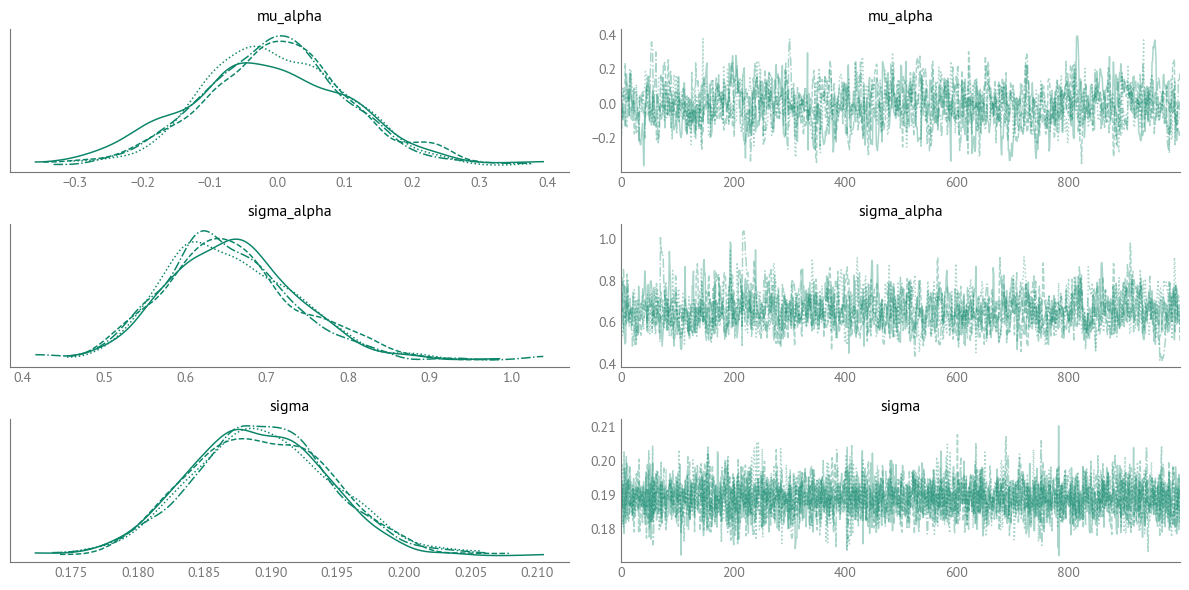

In [36]:
# Plot trace plots for key parameters (HALE)
az.plot_trace(trace_hale, var_names=["mu_alpha", "sigma_alpha", "sigma"], compact=True)
plt.tight_layout()
plt.show()

### Posterior Analysis

Extract and analyze posterior distributions:

In [37]:
# Extract posterior means and credible intervals for beta coefficients (HALE)
beta_summary_hale = az.summary(trace_hale, var_names=["beta"])
beta_summary_hale.index = data_hale["meta"]["predictors"]
beta_summary_hale

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
Gap_Alcohol,0.308,0.032,0.246,0.364,0.001,0.000,3852.0,2704.0,1.0
Gap_Suicide,0.508,0.039,0.433,0.580,0.001,0.001,3537.0,2798.0,1.0
Gap_Homicide,0.390,0.018,0.354,0.423,0.000,0.000,5025.0,2908.0,1.0
Gap_RoadTraffic,0.473,0.021,0.431,0.510,0.000,0.000,3586.0,2560.0,1.0
Gap_Cardiovascular,-0.225,0.023,-0.267,-0.183,0.000,0.000,3410.0,2960.0,1.0
Gap_Diabetes,-0.014,0.021,-0.053,0.025,0.000,0.000,4127.0,2845.0,1.0
Gap_Neoplasms,0.484,0.049,0.393,0.574,0.001,0.001,2570.0,2579.0,1.0
Gap_ChronicRespiratory,0.271,0.034,0.208,0.335,0.001,0.001,3993.0,2746.0,1.0
Gap_LiverDisease,0.239,0.026,0.191,0.289,0.000,0.000,4226.0,2867.0,1.0
Gap_UnintentionalInjury,0.351,0.042,0.273,0.432,0.001,0.001,3965.0,2626.0,1.0


In [38]:
# Write beta coefficients table to HTML
beta_summary_hale_formatted = beta_summary_hale.reset_index().rename(columns={'index': 'Predictor'})
write_html_table(beta_summary_hale_formatted, get_output_filename('jb/tables/beta_coefficients_hale.html', MID_PREDICTORS_TO_INCLUDE, INCLUDE_YEAR_EFFECTS))

In [39]:
# Compute importance measures on original scale
# Extract posterior samples for beta coefficients
beta_samples_hale = trace_hale.posterior["beta"].values.reshape(-1, len(data_hale["meta"]["predictors"]))

# Get SD values used for standardization
X_std_hale = data_hale["meta"]["X_std"]
predictors_hale = data_hale["meta"]["predictors"]

# Compute importance measure: |β_standardized| × SD_original
importance_samples_hale = np.abs(beta_samples_hale) * X_std_hale[np.newaxis, :]

# Create summary table
importance_summary_hale = pd.DataFrame({
    'Predictor': predictors_hale,
    'SD_original': X_std_hale,
    'Beta_standardized_mean': beta_summary_hale['mean'].values,
    'Beta_standardized_hdi_3%': beta_summary_hale['hdi_3%'].values,
    'Beta_standardized_hdi_97%': beta_summary_hale['hdi_97%'].values,
    'Importance_mean': importance_samples_hale.mean(axis=0),
    'Importance_hdi_3%': np.percentile(importance_samples_hale, 3, axis=0),
    'Importance_hdi_97%': np.percentile(importance_samples_hale, 97, axis=0),
})

# Format for display
importance_summary_hale_formatted = importance_summary_hale.copy()
importance_summary_hale_formatted['Beta_standardized'] = (
    importance_summary_hale['Beta_standardized_mean'].round(3).astype(str) + 
    ' [' + importance_summary_hale['Beta_standardized_hdi_3%'].round(3).astype(str) + 
    ', ' + importance_summary_hale['Beta_standardized_hdi_97%'].round(3).astype(str) + ']'
)
importance_summary_hale_formatted['Importance'] = (
    importance_summary_hale['Importance_mean'].round(3).astype(str) + 
    ' [' + importance_summary_hale['Importance_hdi_3%'].round(3).astype(str) + 
    ', ' + importance_summary_hale['Importance_hdi_97%'].round(3).astype(str) + ']'
)

# Select columns for output table and sort by importance
importance_table_hale = importance_summary_hale_formatted[[
    'Predictor', 'SD_original', 'Beta_standardized', 'Importance'
]].copy()
importance_table_hale = importance_table_hale.loc[
    importance_summary_hale.sort_values('Importance_mean', ascending=False).index
].reset_index(drop=True)

print("Importance Measures on Original Scale (HALE Gap Model):")
print(importance_table_hale.to_string(index=False))

# Write to HTML
write_html_table(importance_table_hale, get_output_filename('jb/tables/importance_measures_hale.html', MID_PREDICTORS_TO_INCLUDE, INCLUDE_YEAR_EFFECTS))

Importance Measures on Original Scale (HALE Gap Model):
              Predictor  SD_original       Beta_standardized              Importance
          Gap_Neoplasms    38.423755    0.484 [0.393, 0.574] 18.599 [14.999, 22.027]
     Gap_Cardiovascular    35.479204 -0.225 [-0.267, -0.183]    7.987 [6.497, 9.483]
Gap_UnintentionalInjury    15.917237    0.351 [0.273, 0.432]    5.585 [4.332, 6.869]
           Gap_Homicide    13.918878     0.39 [0.354, 0.423]    5.425 [4.944, 5.902]
            Gap_Suicide    10.075211     0.508 [0.433, 0.58]     5.117 [4.372, 5.85]
Mid_UnintentionalInjury    11.536231   -0.404 [-0.46, -0.35]    4.661 [4.025, 5.297]
 Gap_ChronicRespiratory    10.729284    0.271 [0.208, 0.335]    2.902 [2.203, 3.575]
        Gap_RoadTraffic     5.936859     0.473 [0.431, 0.51]    2.808 [2.572, 3.048]
       Gap_LiverDisease     9.889003    0.239 [0.191, 0.289]    2.363 [1.871, 2.845]
            Gap_Alcohol     6.204189    0.308 [0.246, 0.364]    1.908 [1.537, 2.275]
         

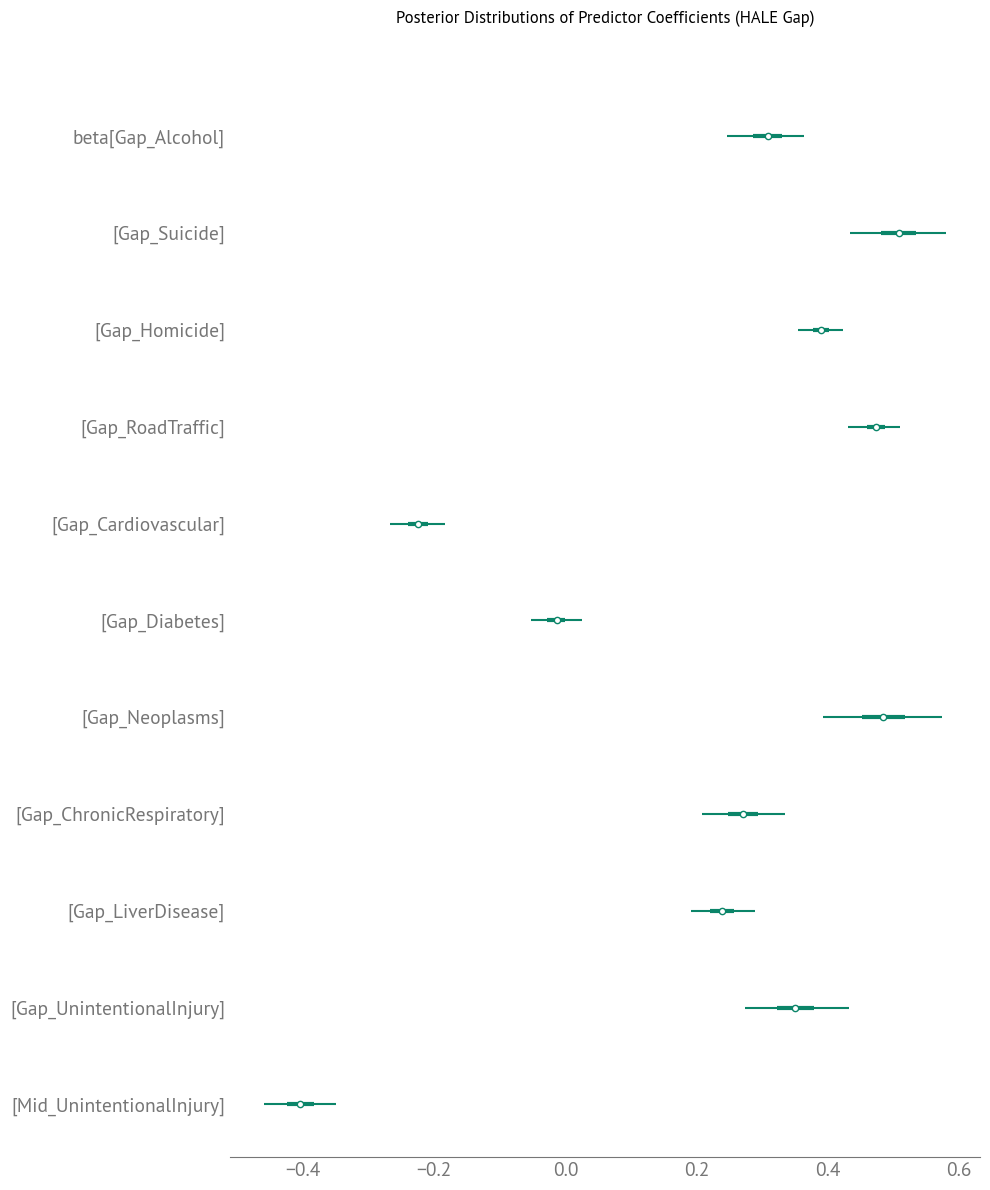

In [40]:
# Plot posterior distributions of beta coefficients (HALE)
az.plot_forest(trace_hale, var_names=["beta"], combined=True, figsize=(10, 12))
plt.title("Posterior Distributions of Predictor Coefficients (HALE Gap)")
plt.tight_layout()
plt.savefig(get_output_filename('jb/figs/posterior_forest_beta_hale.png', MID_PREDICTORS_TO_INCLUDE, INCLUDE_YEAR_EFFECTS), dpi=300, bbox_inches='tight')
plt.show()

In [41]:
# Extract posterior means and credible intervals for alpha coefficients (country intercepts, HALE)
alpha_summary_hale = az.summary(trace_hale, var_names=["alpha"])
alpha_summary_hale.index = data_hale["meta"]["countries"]
alpha_summary_hale

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
AUS,-0.090,0.056,-0.195,0.015,0.001,0.001,4590.0,3456.0,1.0
AUT,-0.550,0.065,-0.674,-0.433,0.001,0.001,3996.0,3623.0,1.0
BEL,-0.892,0.085,-1.056,-0.733,0.001,0.001,3923.0,2589.0,1.0
CAN,0.432,0.066,0.311,0.552,0.001,0.001,3160.0,2997.0,1.0
CHE,0.027,0.057,-0.082,0.130,0.001,0.001,4028.0,3616.0,1.0
CHL,-0.627,0.080,-0.778,-0.480,0.001,0.001,3157.0,2482.0,1.0
COL,0.171,0.138,-0.095,0.425,0.003,0.002,2851.0,3025.0,1.0
CRI,-0.250,0.090,-0.421,-0.082,0.002,0.001,2621.0,2797.0,1.0
CZE,0.652,0.057,0.549,0.765,0.001,0.001,3254.0,2948.0,1.0
DEU,-1.160,0.056,-1.274,-1.062,0.001,0.001,4463.0,3220.0,1.0


In [42]:
# Write alpha coefficients table to HTML
alpha_summary_hale_formatted = alpha_summary_hale.reset_index().rename(columns={'index': 'Country'})
write_html_table(alpha_summary_hale_formatted, get_output_filename('jb/tables/alpha_coefficients_hale.html', MID_PREDICTORS_TO_INCLUDE, INCLUDE_YEAR_EFFECTS))

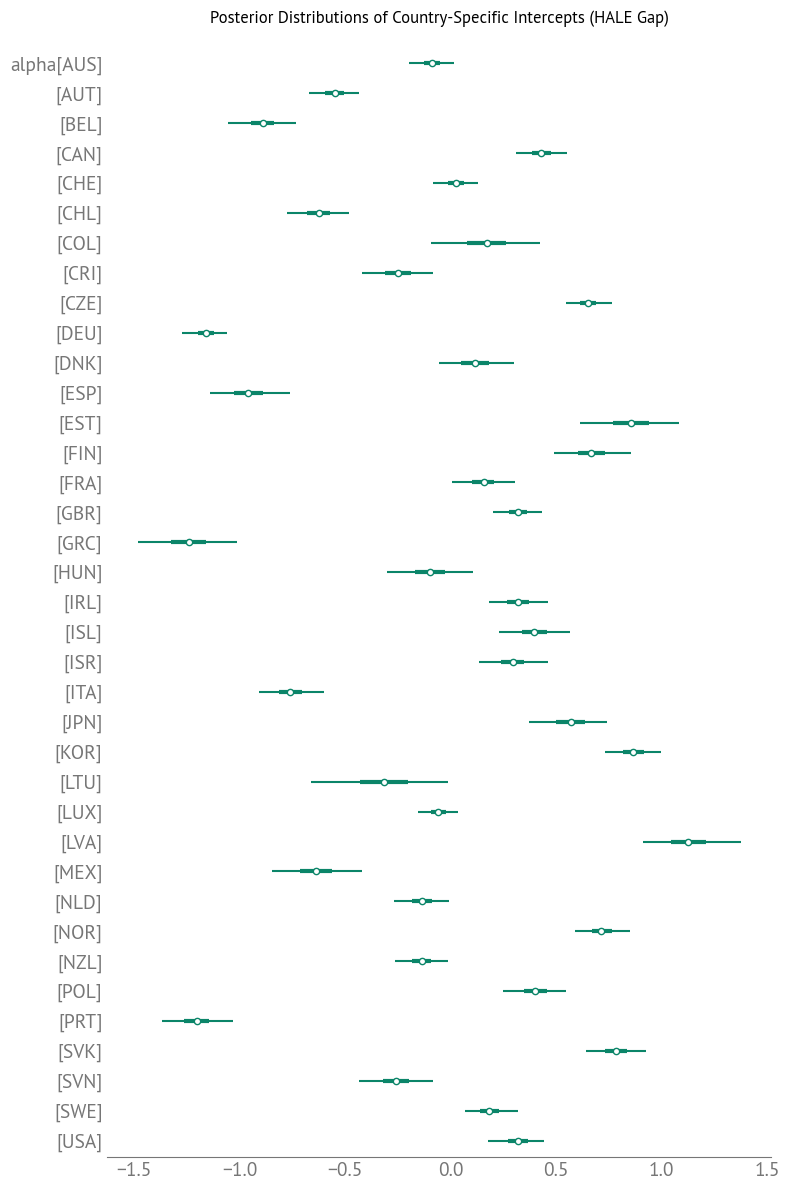

In [43]:
# Plot posterior distributions of country-specific intercepts (alpha) (HALE)
az.plot_forest(trace_hale, var_names=["alpha"], combined=True, figsize=(8, 12))
plt.title("Posterior Distributions of Country-Specific Intercepts (HALE Gap)")
plt.tight_layout()
plt.savefig(get_output_filename('jb/figs/posterior_forest_alpha_hale.png', MID_PREDICTORS_TO_INCLUDE, INCLUDE_YEAR_EFFECTS), dpi=300, bbox_inches='tight')
plt.show()

### Correlations

In [44]:
# Extract posterior samples for beta coefficients (if not already done)
beta_extracted_hale = az.extract(trace_hale)
beta_samples_df_hale = pd.DataFrame(
    beta_extracted_hale['beta'].T,
    columns=data_hale["meta"]["predictors"]
)

# Compute correlation matrix for beta coefficients
beta_corr_hale = beta_samples_df_hale.corr()

# Extract upper triangle (excluding diagonal) and convert to long format
beta_corr_triu = np.triu(beta_corr_hale.values, k=1)
beta_corr_long = []
for i in range(len(beta_corr_hale.index)):
    for j in range(i + 1, len(beta_corr_hale.columns)):
        if not np.isnan(beta_corr_triu[i, j]):
            beta_corr_long.append({
                'Predictor1': beta_corr_hale.index[i],
                'Predictor2': beta_corr_hale.columns[j],
                'Correlation': beta_corr_triu[i, j]
            })

beta_corr_df_hale = pd.DataFrame(beta_corr_long)
beta_corr_df_hale['Abs_Correlation'] = beta_corr_df_hale['Correlation'].abs()
beta_corr_top10_hale = beta_corr_df_hale.nlargest(10, 'Abs_Correlation')[
    ['Predictor1', 'Predictor2', 'Correlation']
].sort_values('Correlation', key=abs, ascending=False)

print("Top 10 correlations among beta coefficients (HALE):")
beta_corr_top10_hale

Top 10 correlations among beta coefficients (HALE):


,Predictor1,Predictor2,Correlation
41,Gap_Diabetes,Gap_ChronicRespiratory,0.406166
45,Gap_Neoplasms,Gap_ChronicRespiratory,-0.405711
30,Gap_RoadTraffic,Gap_ChronicRespiratory,-0.362359
54,Gap_UnintentionalInjury,Mid_UnintentionalInjury,-0.355272
17,Gap_Suicide,Gap_UnintentionalInjury,-0.334452
44,Gap_Diabetes,Mid_UnintentionalInjury,-0.319432
9,Gap_Alcohol,Mid_UnintentionalInjury,-0.317027
38,Gap_Cardiovascular,Gap_UnintentionalInjury,-0.297008
29,Gap_RoadTraffic,Gap_Neoplasms,0.290949
32,Gap_RoadTraffic,Gap_UnintentionalInjury,-0.285497


In [45]:
# Write beta correlations table to HTML
write_html_table(beta_corr_top10_hale, get_output_filename('jb/tables/beta_correlations_top10_hale.html', MID_PREDICTORS_TO_INCLUDE, INCLUDE_YEAR_EFFECTS))

In [46]:
# Extract posterior samples for alpha coefficients (country intercepts)
alpha_extracted_hale = az.extract(trace_hale)
alpha_samples_df_hale = pd.DataFrame(
    alpha_extracted_hale['alpha'].T,
    columns=data_hale["meta"]["countries"]
)

# Compute correlation matrix for alpha coefficients
alpha_corr_hale = alpha_samples_df_hale.corr()

# Extract upper triangle (excluding diagonal) and convert to long format
alpha_corr_triu = np.triu(alpha_corr_hale.values, k=1)
alpha_corr_long = []
for i in range(len(alpha_corr_hale.index)):
    for j in range(i + 1, len(alpha_corr_hale.columns)):
        if not np.isnan(alpha_corr_triu[i, j]):
            alpha_corr_long.append({
                'Country1': alpha_corr_hale.index[i],
                'Country2': alpha_corr_hale.columns[j],
                'Correlation': alpha_corr_triu[i, j]
            })

alpha_corr_df_hale = pd.DataFrame(alpha_corr_long)
alpha_corr_df_hale['Abs_Correlation'] = alpha_corr_df_hale['Correlation'].abs()
alpha_corr_top10_hale = alpha_corr_df_hale.nlargest(10, 'Abs_Correlation')[
    ['Country1', 'Country2', 'Correlation']
].sort_values('Correlation', key=abs, ascending=False)

print("Top 10 correlations among alpha coefficients (country intercepts, HALE):")
alpha_corr_top10_hale

Top 10 correlations among alpha coefficients (country intercepts, HALE):


,Country1,Country2,Correlation
379,EST,LVA,0.771556
392,FIN,GRC,-0.739465
191,CHL,MEX,0.699075
350,ESP,ITA,0.694942
247,CRI,LTU,-0.686652
589,LTU,LVA,0.683704
471,GRC,PRT,0.679171
533,ISR,LTU,-0.674484
377,EST,LTU,0.668592
201,COL,CRI,0.667566


In [47]:
# Write alpha correlations table to HTML
write_html_table(alpha_corr_top10_hale, get_output_filename('jb/tables/alpha_correlations_top10_hale.html', MID_PREDICTORS_TO_INCLUDE, INCLUDE_YEAR_EFFECTS))

### Comparison with Cross-Sectional Elastic Net Model

In [48]:
def plot_bayesian_elasticnet_comparison(beta_samples_df, elastic_net_coefs, common_predictors,
                                        title, output_filename, n_rows=5, n_cols=4):
    """
    Create comparison visualization showing posterior distributions vs Elastic Net coefficients.
    
    Parameters
    ----------
    beta_samples_df : pd.DataFrame
        DataFrame with posterior samples (columns = predictors, rows = samples)
    elastic_net_coefs : pd.DataFrame
        DataFrame with Elastic Net coefficients (indexed by predictor)
    common_predictors : list
        List of common predictors between Bayesian and Elastic Net models
    title : str
        Title for the plot
    output_filename : str
        Filename to save the figure
    n_rows : int
        Number of rows in subplot grid (default: 5)
    n_cols : int
        Number of columns in subplot grid (default: 4)
    """
    n_plots = n_rows * n_cols
    
    # Select predictors to plot (prioritize those with non-zero EN coefficients)
    predictors_to_plot = elastic_net_coefs.loc[common_predictors].sort_values(
        'ElasticNet_Coefficient', key=abs, ascending=False
    ).head(n_plots).index.tolist()
    
    # If we have fewer predictors than subplots, use all predictors
    if len(common_predictors) < n_plots:
        predictors_to_plot = common_predictors
        n_rows = int(np.ceil(len(predictors_to_plot) / n_cols))
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 20))
    axes = axes.flatten() if n_rows > 1 else [axes] if n_cols == 1 else axes.flatten()
    
    for i, pred in enumerate(predictors_to_plot):
        ax = axes[i]
        
        # Get posterior samples for this predictor
        posterior_samples = beta_samples_df[pred].values
        
        # Get Elastic Net coefficient
        en_coef = elastic_net_coefs.loc[pred, 'ElasticNet_Coefficient']
        
        # Plot posterior distribution with HDI using az.plot_dist
        az.plot_dist(posterior_samples, ax=ax, color=AIBM_COLORS['crimson'])
        
        # Add vertical line for Elastic Net coefficient
        ax.axvline(en_coef, color=AIBM_COLORS['blue'], linestyle='--', linewidth=2, 
                   label=f'Elastic Net: {en_coef:.3f}')
        
        # Add vertical line for posterior mean
        posterior_mean = posterior_samples.mean()
        ax.axvline(posterior_mean, color=AIBM_COLORS['green'], linestyle='-', linewidth=2,
                   label=f'Posterior mean: {posterior_mean:.3f}')
        
        ax.set_xlabel('Coefficient')
        ax.set_ylabel('Density')
        ax.set_title(pred, fontsize=10)
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)
    
    # Hide unused subplots
    for i in range(len(predictors_to_plot), len(axes)):
        axes[i].set_visible(False)
    
    plt.suptitle(title, fontsize=14, y=0.995)
    plt.tight_layout()
    # Update output filename with suffix
    output_filename_suffixed = get_output_filename(output_filename, MID_PREDICTORS_TO_INCLUDE, INCLUDE_YEAR_EFFECTS)
    plt.savefig(output_filename_suffixed, dpi=300, bbox_inches='tight')
    plt.show()

In [49]:
# Load Elastic Net coefficients from cross-sectional model
cutoff_year = 2019  # Match the cutoff year used in cross-sectional analysis
elastic_net_coefs_hale = pd.read_csv(f'../data/elasticnet_coefficients_hale_{cutoff_year}.csv')
elastic_net_coefs_hale = elastic_net_coefs_hale.set_index('Predictor')

print(f"Loaded {len(elastic_net_coefs_hale)} Elastic Net coefficients for HALE")
print(f"Bayesian model has {len(data_hale['meta']['predictors'])} predictors")

Loaded 22 Elastic Net coefficients for HALE
Bayesian model has 11 predictors


In [50]:
# Extract posterior samples for beta coefficients
beta_extracted_hale = az.extract(trace_hale)

# Create DataFrame with predictor names
beta_samples_df_hale = pd.DataFrame(
    beta_extracted_hale['beta'].T,
    columns=data_hale["meta"]["predictors"]
)

print(f"Posterior samples shape: {beta_samples_df_hale.shape}")

Posterior samples shape: (4000, 11)


In [51]:
# Match predictors between Bayesian and Elastic Net models
# Find common predictors
common_predictors = set(beta_samples_df_hale.columns) & set(elastic_net_coefs_hale.index)
common_predictors = sorted(list(common_predictors))

print(f"Common predictors: {len(common_predictors)}")
print(f"Predictors only in Bayesian model: {len(set(beta_samples_df_hale.columns) - set(elastic_net_coefs_hale.index))}")
print(f"Predictors only in Elastic Net model: {len(set(elastic_net_coefs_hale.index) - set(beta_samples_df_hale.columns))}")

Common predictors: 11
Predictors only in Bayesian model: 0
Predictors only in Elastic Net model: 11


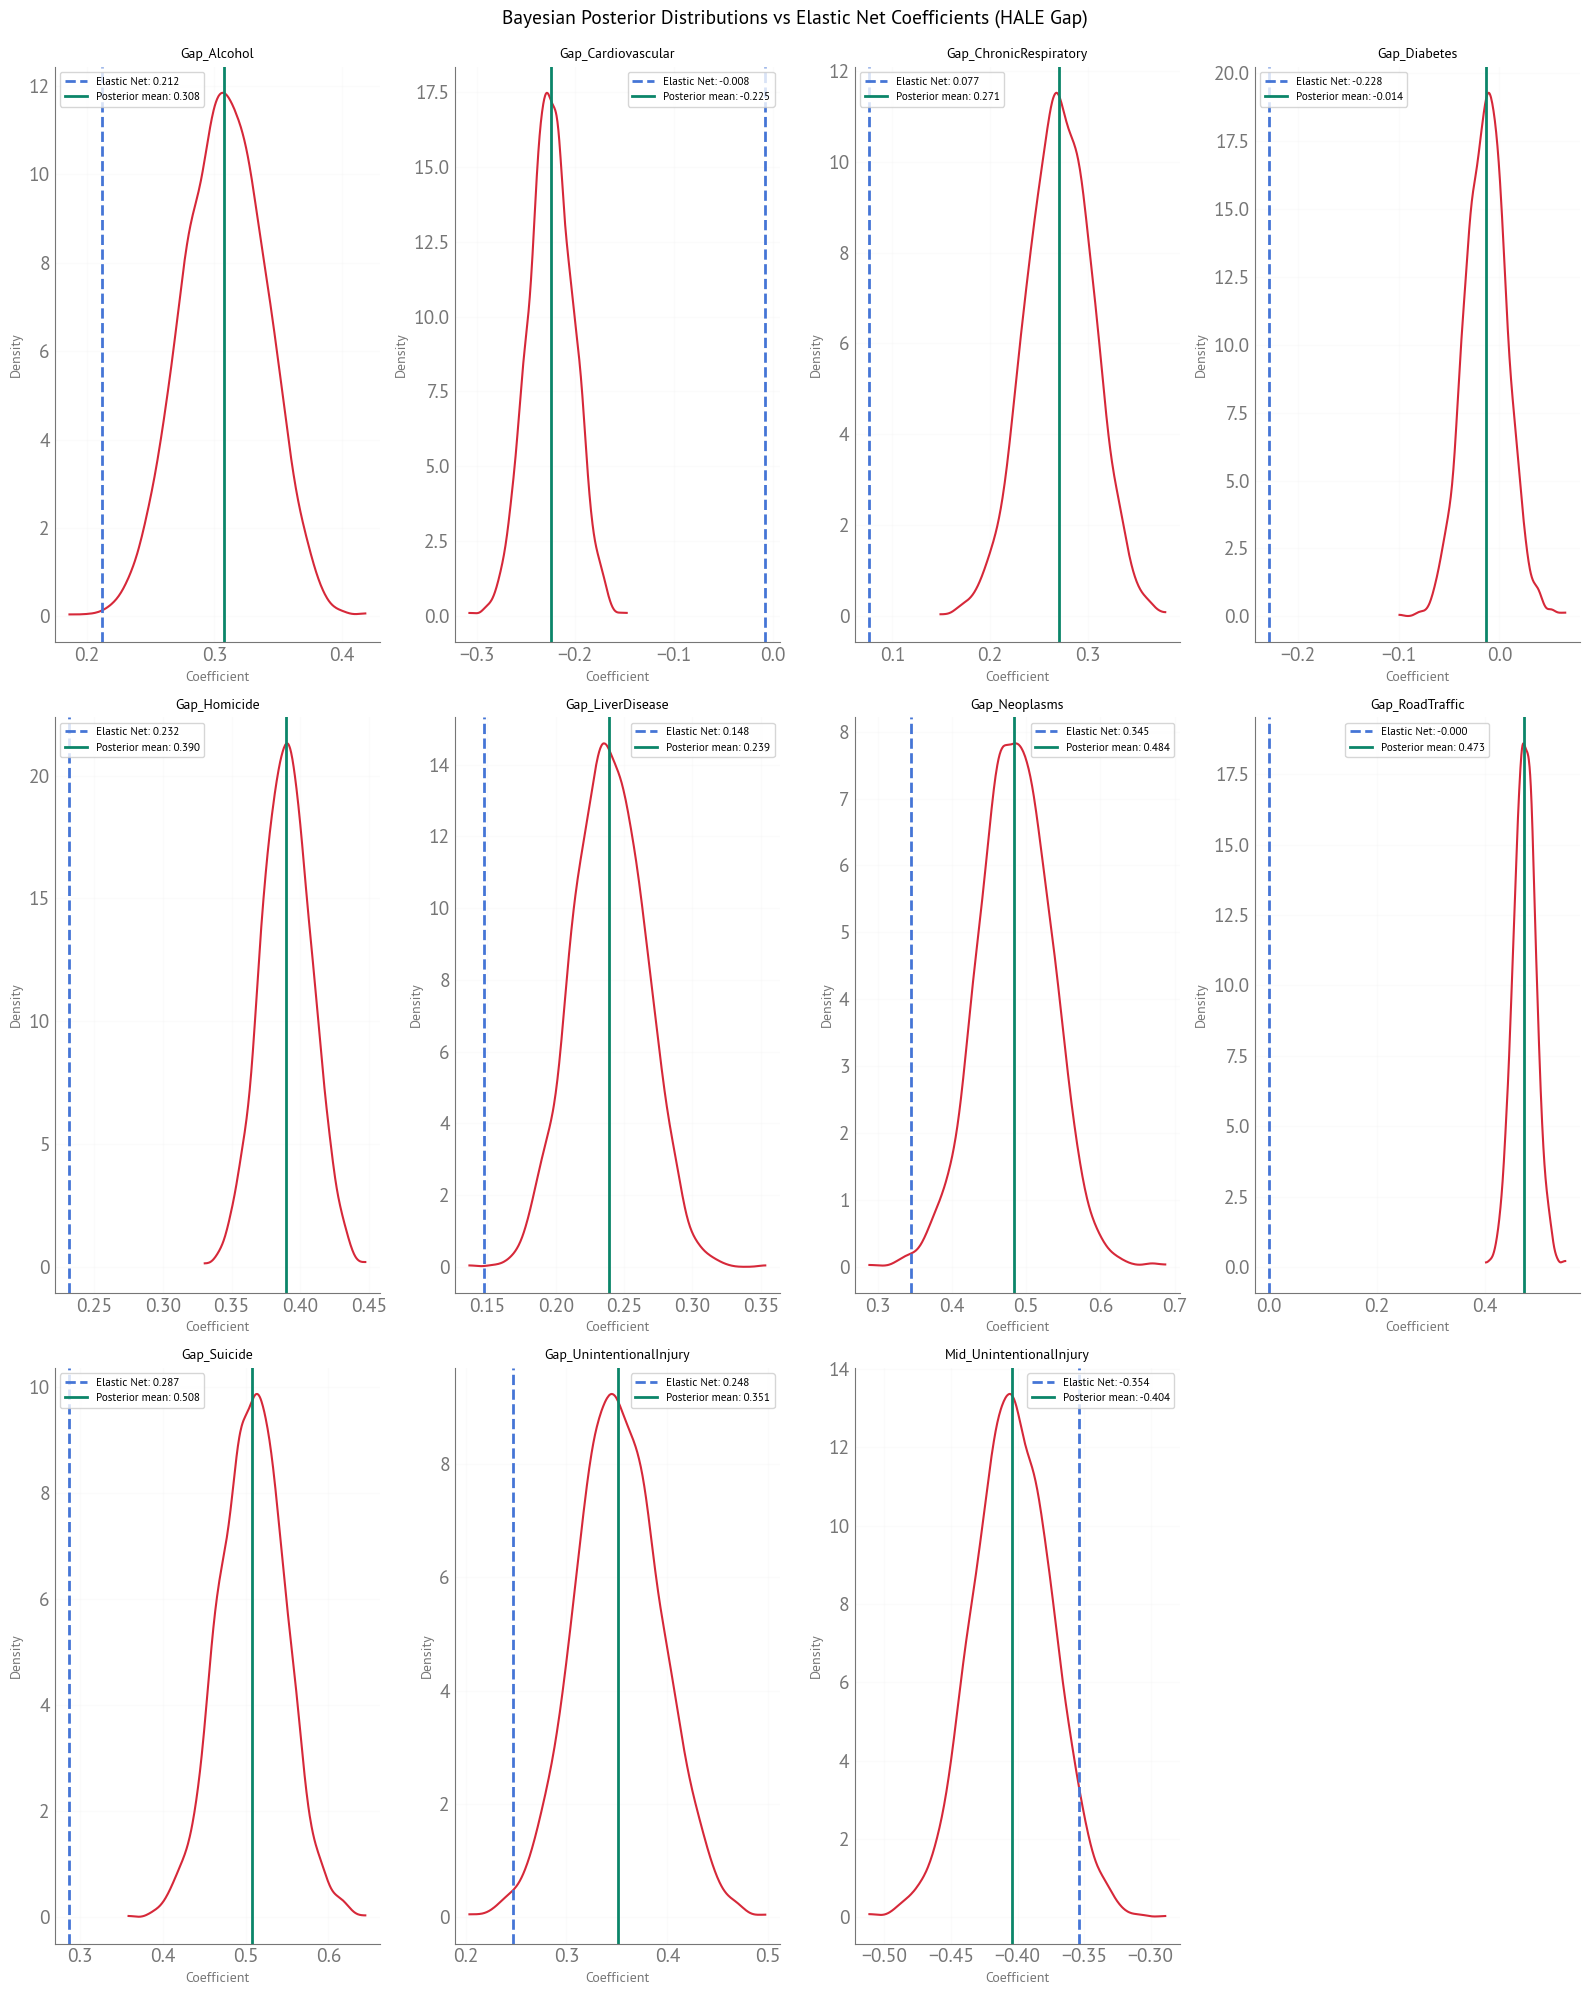

In [52]:
# Create comparison visualization using the function
plot_bayesian_elasticnet_comparison(
    beta_samples_df_hale,
    elastic_net_coefs_hale,
    common_predictors,
    title='Bayesian Posterior Distributions vs Elastic Net Coefficients (HALE Gap)',
    output_filename='jb/figs/bayesian_elasticnet_comparison_hale.png'
)

In [53]:
# Create summary comparison table
comparison_table_hale = pd.DataFrame({
    'Predictor': common_predictors,
    'ElasticNet_Coefficient': [elastic_net_coefs_hale.loc[p, 'ElasticNet_Coefficient'] for p in common_predictors],
    'Bayesian_Mean': [beta_samples_df_hale[p].mean() for p in common_predictors],
    'Bayesian_Std': [beta_samples_df_hale[p].std() for p in common_predictors],
    'Bayesian_CI_Lower': [np.percentile(beta_samples_df_hale[p].values, 2.5) for p in common_predictors],
    'Bayesian_CI_Upper': [np.percentile(beta_samples_df_hale[p].values, 97.5) for p in common_predictors],
    'Difference': [beta_samples_df_hale[p].mean() - elastic_net_coefs_hale.loc[p, 'ElasticNet_Coefficient'] 
                   for p in common_predictors]
})

comparison_table_hale = comparison_table_hale.sort_values('ElasticNet_Coefficient', key=abs, ascending=False)
comparison_table_hale.head(20)

,Predictor,ElasticNet_Coefficient,Bayesian_Mean,Bayesian_Std,Bayesian_CI_Lower,Bayesian_CI_Upper,Difference
10,Mid_UnintentionalInjury,-0.354215,-0.404017,0.029470,-0.461924,-0.346667,-0.049802
6,Gap_Neoplasms,0.344777,0.484047,0.049040,0.384500,0.577829,0.139270
8,Gap_Suicide,0.287401,0.507915,0.039226,0.430302,0.585660,0.220514
9,Gap_UnintentionalInjury,0.247515,0.350856,0.042266,0.269131,0.434796,0.103341
4,Gap_Homicide,0.231818,0.389788,0.018202,0.353909,0.425423,0.157970
3,Gap_Diabetes,-0.228147,-0.013757,0.020650,-0.054713,0.026213,0.214390
0,Gap_Alcohol,0.211845,0.307612,0.032039,0.245674,0.368676,0.095767
5,Gap_LiverDisease,0.147692,0.238948,0.026248,0.187801,0.289256,0.091256
2,Gap_ChronicRespiratory,0.076506,0.270519,0.033915,0.203189,0.335396,0.194013
1,Gap_Cardiovascular,-0.007703,-0.225111,0.022706,-0.269381,-0.180220,-0.217408


## Life Expectancy Gap Model

### Build Model

In [54]:
# Build model for Life Expectancy gap
model_le = build_random_intercept_panel_model(data_le, include_year_effects=INCLUDE_YEAR_EFFECTS)
if INCLUDE_YEAR_EFFECTS:
    print("Year effects (GRW): INCLUDED")
else:
    print("Year effects (GRW): NOT INCLUDED")

Year effects (GRW): NOT INCLUDED


### Sample from Posterior

In [55]:
# Sample from Life Expectancy model
with model_le:
    trace_le = pm.sample(
        nuts_sampler='nutpie'
    )

# Add log-likelihood for WAIC/LOO computation (nutpie doesn't save it by default)
trace_le = add_log_likelihood_to_trace(model_le, trace_le)

Progress,Draws,Divergences,Step Size,Gradients/Draw
,2000,0,0.25,47
,2000,0,0.22,63
,2000,0,0.25,15
,2000,0,0.23,15


Output()

### Model Diagnostics

Check convergence and sampling quality:

In [56]:
# Life Expectancy model diagnostics
az.summary(trace_le, var_names=["mu_alpha", "sigma_alpha", "sigma", "beta"])

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
mu_alpha,0.002,0.096,-0.176,0.179,0.003,0.002,880.0,1394.0,1.01
sigma_alpha,0.589,0.074,0.454,0.721,0.002,0.001,1014.0,1333.0,1.00
sigma,0.208,0.006,0.198,0.219,0.000,0.000,3813.0,2513.0,1.00
beta[Gap_Alcohol],0.350,0.036,0.288,0.421,0.001,0.001,3014.0,2366.0,1.00
beta[Gap_Suicide],0.572,0.043,0.493,0.651,0.001,0.001,2961.0,2745.0,1.00
beta[Gap_Homicide],0.452,0.021,0.412,0.489,0.000,0.000,4754.0,2604.0,1.00
beta[Gap_RoadTraffic],0.437,0.023,0.392,0.478,0.000,0.000,3720.0,3425.0,1.00
beta[Gap_Cardiovascular],-0.178,0.024,-0.224,-0.135,0.000,0.000,2836.0,3087.0,1.00
beta[Gap_Diabetes],-0.004,0.023,-0.045,0.040,0.000,0.000,4352.0,3161.0,1.00
beta[Gap_Neoplasms],0.504,0.052,0.408,0.602,0.001,0.001,2121.0,2264.0,1.00


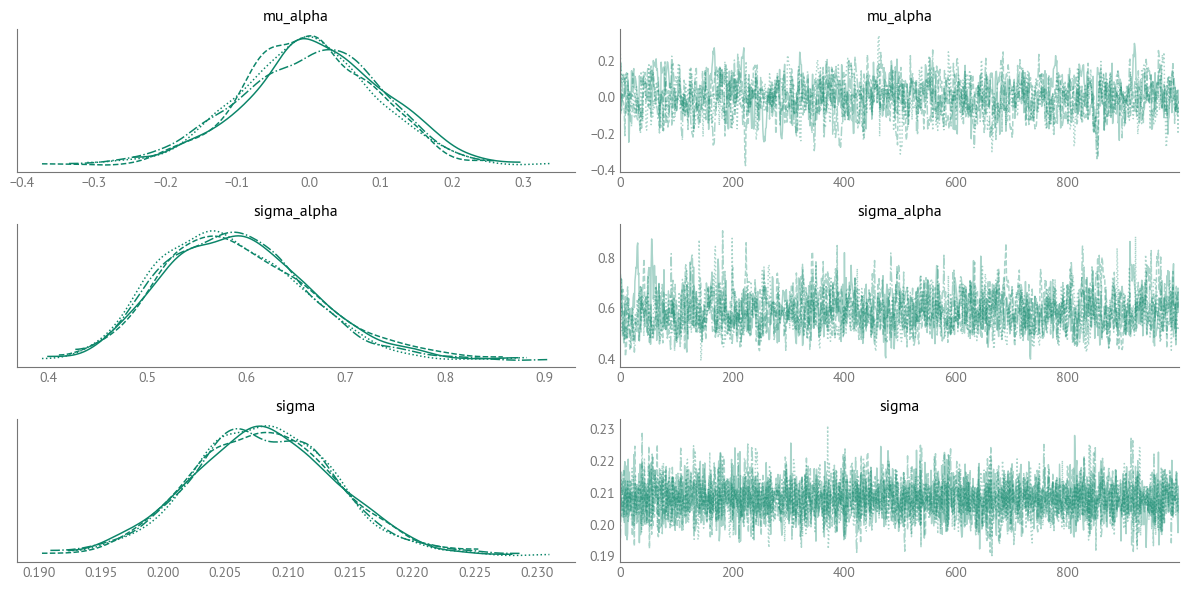

In [57]:
# Plot trace plots for key parameters (Life Expectancy)
az.plot_trace(trace_le, var_names=["mu_alpha", "sigma_alpha", "sigma"], compact=True)
plt.tight_layout()
plt.show()

### Posterior Analysis

Extract and analyze posterior distributions:

In [58]:
# Extract posterior means and credible intervals for beta coefficients (Life Expectancy)
beta_summary_le = az.summary(trace_le, var_names=["beta"])
beta_summary_le.index = data_le["meta"]["predictors"]
beta_summary_le

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
Gap_Alcohol,0.350,0.036,0.288,0.421,0.001,0.001,3014.0,2366.0,1.0
Gap_Suicide,0.572,0.043,0.493,0.651,0.001,0.001,2961.0,2745.0,1.0
Gap_Homicide,0.452,0.021,0.412,0.489,0.000,0.000,4754.0,2604.0,1.0
Gap_RoadTraffic,0.437,0.023,0.392,0.478,0.000,0.000,3720.0,3425.0,1.0
Gap_Cardiovascular,-0.178,0.024,-0.224,-0.135,0.000,0.000,2836.0,3087.0,1.0
Gap_Diabetes,-0.004,0.023,-0.045,0.040,0.000,0.000,4352.0,3161.0,1.0
Gap_Neoplasms,0.504,0.052,0.408,0.602,0.001,0.001,2121.0,2264.0,1.0
Gap_ChronicRespiratory,0.351,0.035,0.281,0.413,0.001,0.001,3920.0,2562.0,1.0
Gap_LiverDisease,0.280,0.028,0.228,0.333,0.000,0.001,4211.0,2845.0,1.0
Gap_UnintentionalInjury,0.354,0.045,0.268,0.436,0.001,0.001,3464.0,2575.0,1.0


In [59]:
# Write beta coefficients table to HTML
beta_summary_le_formatted = beta_summary_le.reset_index().rename(columns={'index': 'Predictor'})
write_html_table(beta_summary_le_formatted, get_output_filename('jb/tables/beta_coefficients_le.html', MID_PREDICTORS_TO_INCLUDE, INCLUDE_YEAR_EFFECTS))

In [60]:
# Compute importance measures on original scale
# Extract posterior samples for beta coefficients
beta_samples_le = trace_le.posterior["beta"].values.reshape(-1, len(data_le["meta"]["predictors"]))

# Get SD values used for standardization
X_std_le = data_le["meta"]["X_std"]
predictors_le = data_le["meta"]["predictors"]

# Compute importance measure: |β_standardized| × SD_original
importance_samples_le = np.abs(beta_samples_le) * X_std_le[np.newaxis, :]

# Create summary table
importance_summary_le = pd.DataFrame({
    'Predictor': predictors_le,
    'SD_original': X_std_le,
    'Beta_standardized_mean': beta_summary_le['mean'].values,
    'Beta_standardized_hdi_3%': beta_summary_le['hdi_3%'].values,
    'Beta_standardized_hdi_97%': beta_summary_le['hdi_97%'].values,
    'Importance_mean': importance_samples_le.mean(axis=0),
    'Importance_hdi_3%': np.percentile(importance_samples_le, 3, axis=0),
    'Importance_hdi_97%': np.percentile(importance_samples_le, 97, axis=0),
})

# Format for display
importance_summary_le_formatted = importance_summary_le.copy()
importance_summary_le_formatted['Beta_standardized'] = (
    importance_summary_le['Beta_standardized_mean'].round(3).astype(str) + 
    ' [' + importance_summary_le['Beta_standardized_hdi_3%'].round(3).astype(str) + 
    ', ' + importance_summary_le['Beta_standardized_hdi_97%'].round(3).astype(str) + ']'
)
importance_summary_le_formatted['Importance'] = (
    importance_summary_le['Importance_mean'].round(3).astype(str) + 
    ' [' + importance_summary_le['Importance_hdi_3%'].round(3).astype(str) + 
    ', ' + importance_summary_le['Importance_hdi_97%'].round(3).astype(str) + ']'
)

# Select columns for output table and sort by importance
importance_table_le = importance_summary_le_formatted[[
    'Predictor', 'SD_original', 'Beta_standardized', 'Importance'
]].copy()
importance_table_le = importance_table_le.loc[
    importance_summary_le.sort_values('Importance_mean', ascending=False).index
].reset_index(drop=True)

print("Importance Measures on Original Scale (Life Expectancy Gap Model):")
print(importance_table_le.to_string(index=False))

# Write to HTML
write_html_table(importance_table_le, get_output_filename('jb/tables/importance_measures_le.html', MID_PREDICTORS_TO_INCLUDE, INCLUDE_YEAR_EFFECTS))

Importance Measures on Original Scale (Life Expectancy Gap Model):
              Predictor  SD_original       Beta_standardized              Importance
          Gap_Neoplasms    38.423755    0.504 [0.408, 0.602] 19.378 [15.699, 23.129]
     Gap_Cardiovascular    35.479204 -0.178 [-0.224, -0.135]    6.315 [4.733, 7.901]
           Gap_Homicide    13.918878    0.452 [0.412, 0.489]     6.293 [5.756, 6.84]
            Gap_Suicide    10.075211    0.572 [0.493, 0.651]    5.761 [4.939, 6.546]
Gap_UnintentionalInjury    15.917237    0.354 [0.268, 0.436]    5.635 [4.278, 6.959]
Mid_UnintentionalInjury    11.536231 -0.472 [-0.532, -0.411]    5.448 [4.745, 6.155]
 Gap_ChronicRespiratory    10.729284    0.351 [0.281, 0.413]     3.761 [3.05, 4.482]
       Gap_LiverDisease     9.889003     0.28 [0.228, 0.333]    2.767 [2.242, 3.288]
        Gap_RoadTraffic     5.936859    0.437 [0.392, 0.478]     2.597 [2.337, 2.85]
            Gap_Alcohol     6.204189     0.35 [0.288, 0.421]    2.169 [1.758, 2.585

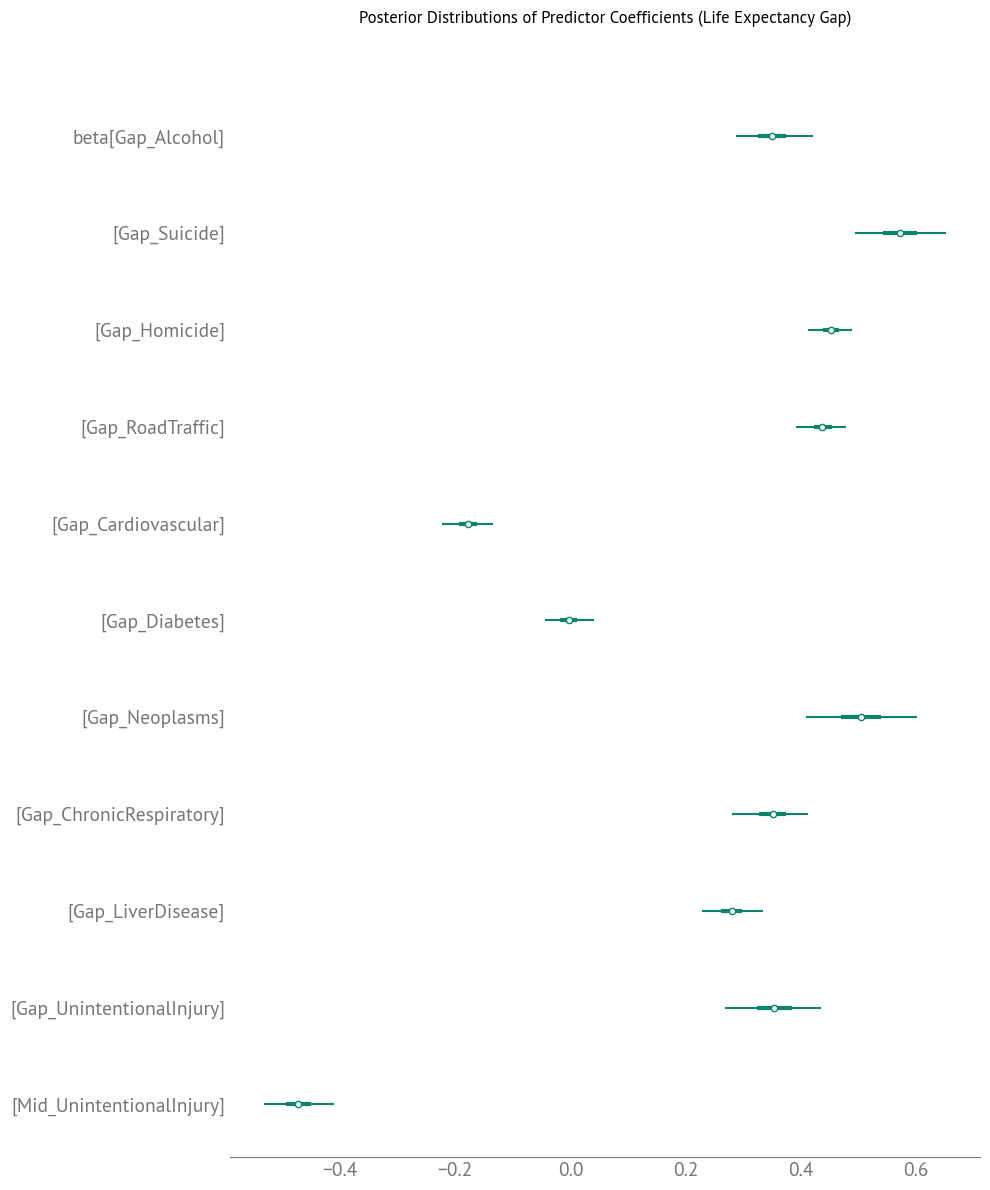

In [61]:
# Plot posterior distributions of beta coefficients (Life Expectancy)
az.plot_forest(trace_le, var_names=["beta"], combined=True, figsize=(10, 12))
plt.title("Posterior Distributions of Predictor Coefficients (Life Expectancy Gap)")
plt.tight_layout()
plt.savefig(get_output_filename('jb/figs/posterior_forest_beta_le.png', MID_PREDICTORS_TO_INCLUDE, INCLUDE_YEAR_EFFECTS), dpi=300, bbox_inches='tight')
plt.show()

In [62]:
# Extract posterior means and credible intervals for alpha coefficients (country intercepts, Life Expectancy)
alpha_summary_le = az.summary(trace_le, var_names=["alpha"])
alpha_summary_le.index = data_le["meta"]["countries"]
alpha_summary_le

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
AUS,-0.336,0.062,-0.453,-0.220,0.001,0.001,4461.0,3622.0,1.0
AUT,-0.442,0.070,-0.575,-0.312,0.001,0.001,4217.0,3323.0,1.0
BEL,-0.572,0.091,-0.742,-0.398,0.001,0.001,3816.0,2882.0,1.0
CAN,0.208,0.067,0.079,0.330,0.001,0.001,2617.0,2847.0,1.0
CHE,0.088,0.063,-0.035,0.202,0.001,0.001,4126.0,2992.0,1.0
CHL,-0.181,0.086,-0.346,-0.022,0.002,0.001,2938.0,3297.0,1.0
COL,-0.536,0.149,-0.821,-0.258,0.003,0.002,3076.0,2705.0,1.0
CRI,-0.508,0.097,-0.685,-0.326,0.002,0.001,2839.0,3209.0,1.0
CZE,0.197,0.060,0.083,0.306,0.001,0.001,3268.0,3169.0,1.0
DEU,-0.485,0.061,-0.596,-0.370,0.001,0.001,4323.0,3457.0,1.0


In [63]:
# Write alpha coefficients table to HTML
alpha_summary_le_formatted = alpha_summary_le.reset_index().rename(columns={'index': 'Country'})
write_html_table(alpha_summary_le_formatted, get_output_filename('jb/tables/alpha_coefficients_le.html', MID_PREDICTORS_TO_INCLUDE, INCLUDE_YEAR_EFFECTS))

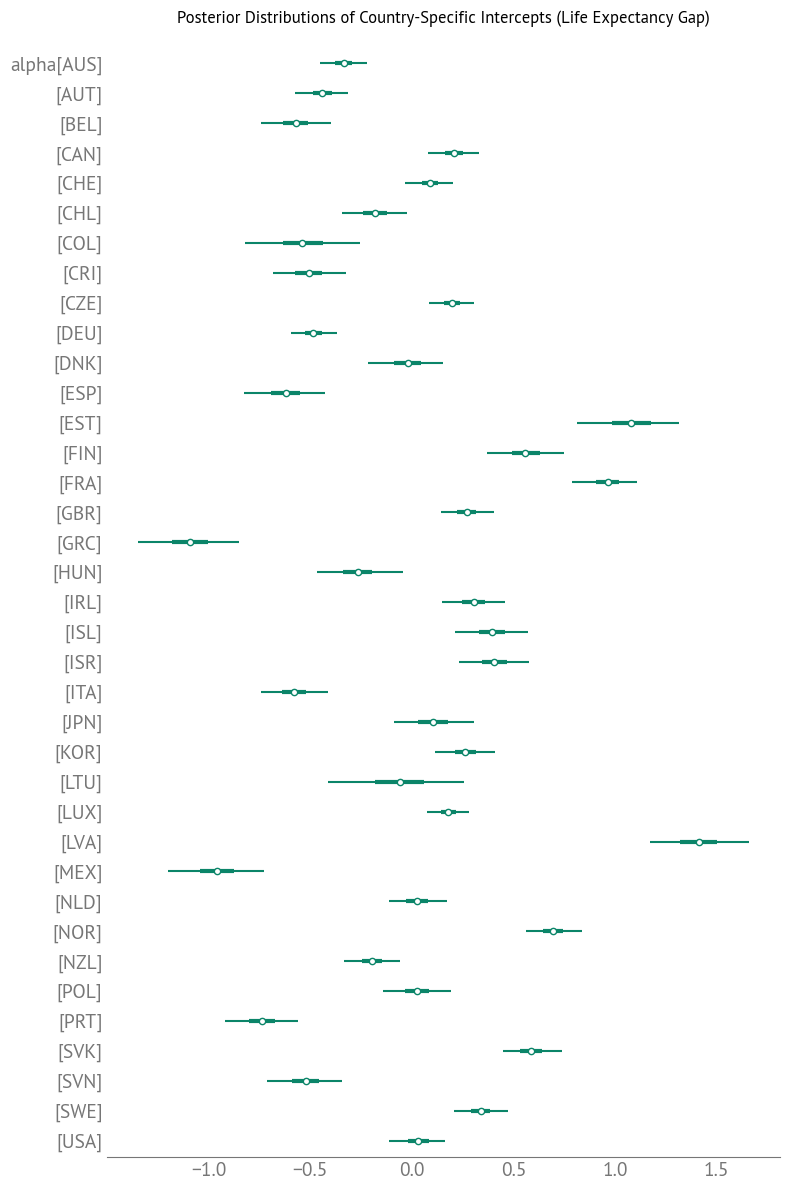

In [64]:
# Plot posterior distributions of country-specific intercepts (alpha) (Life Expectancy)
az.plot_forest(trace_le, var_names=["alpha"], combined=True, figsize=(8, 12))
plt.title("Posterior Distributions of Country-Specific Intercepts (Life Expectancy Gap)")
plt.tight_layout()
plt.savefig(get_output_filename('jb/figs/posterior_forest_alpha_le.png', MID_PREDICTORS_TO_INCLUDE, INCLUDE_YEAR_EFFECTS), dpi=300, bbox_inches='tight')
plt.show()

### Correlations

In [65]:
# Extract posterior samples for beta coefficients (if not already done)
beta_extracted_le = az.extract(trace_le)
beta_samples_df_le = pd.DataFrame(
    beta_extracted_le['beta'].T,
    columns=data_le["meta"]["predictors"]
)

# Compute correlation matrix for beta coefficients
beta_corr_le = beta_samples_df_le.corr()

# Extract upper triangle (excluding diagonal) and convert to long format
beta_corr_triu = np.triu(beta_corr_le.values, k=1)
beta_corr_long = []
for i in range(len(beta_corr_le.index)):
    for j in range(i + 1, len(beta_corr_le.columns)):
        if not np.isnan(beta_corr_triu[i, j]):
            beta_corr_long.append({
                'Predictor1': beta_corr_le.index[i],
                'Predictor2': beta_corr_le.columns[j],
                'Correlation': beta_corr_triu[i, j]
            })

beta_corr_df_le = pd.DataFrame(beta_corr_long)
beta_corr_df_le['Abs_Correlation'] = beta_corr_df_le['Correlation'].abs()
beta_corr_top10_le = beta_corr_df_le.nlargest(10, 'Abs_Correlation')[
    ['Predictor1', 'Predictor2', 'Correlation']
].sort_values('Correlation', key=abs, ascending=False)

print("Top 10 correlations among beta coefficients (Life Expectancy):")
beta_corr_top10_le

Top 10 correlations among beta coefficients (Life Expectancy):


,Predictor1,Predictor2,Correlation
41,Gap_Diabetes,Gap_ChronicRespiratory,0.399176
45,Gap_Neoplasms,Gap_ChronicRespiratory,-0.381027
54,Gap_UnintentionalInjury,Mid_UnintentionalInjury,-0.377488
30,Gap_RoadTraffic,Gap_ChronicRespiratory,-0.346689
44,Gap_Diabetes,Mid_UnintentionalInjury,-0.346040
29,Gap_RoadTraffic,Gap_Neoplasms,0.316110
17,Gap_Suicide,Gap_UnintentionalInjury,-0.306034
9,Gap_Alcohol,Mid_UnintentionalInjury,-0.297754
32,Gap_RoadTraffic,Gap_UnintentionalInjury,-0.294332
38,Gap_Cardiovascular,Gap_UnintentionalInjury,-0.267817


In [66]:
# Write beta correlations table to HTML
write_html_table(beta_corr_top10_le, get_output_filename('jb/tables/beta_correlations_top10_le.html', MID_PREDICTORS_TO_INCLUDE, INCLUDE_YEAR_EFFECTS))

In [67]:
# Extract posterior samples for alpha coefficients (country intercepts)
alpha_extracted_le = az.extract(trace_le)
alpha_samples_df_le = pd.DataFrame(
    alpha_extracted_le['alpha'].T,
    columns=data_le["meta"]["countries"]
)

# Compute correlation matrix for alpha coefficients
alpha_corr_le = alpha_samples_df_le.corr()

# Extract upper triangle (excluding diagonal) and convert to long format
alpha_corr_triu = np.triu(alpha_corr_le.values, k=1)
alpha_corr_long = []
for i in range(len(alpha_corr_le.index)):
    for j in range(i + 1, len(alpha_corr_le.columns)):
        if not np.isnan(alpha_corr_triu[i, j]):
            alpha_corr_long.append({
                'Country1': alpha_corr_le.index[i],
                'Country2': alpha_corr_le.columns[j],
                'Correlation': alpha_corr_triu[i, j]
            })

alpha_corr_df_le = pd.DataFrame(alpha_corr_long)
alpha_corr_df_le['Abs_Correlation'] = alpha_corr_df_le['Correlation'].abs()
alpha_corr_top10_le = alpha_corr_df_le.nlargest(10, 'Abs_Correlation')[
    ['Country1', 'Country2', 'Correlation']
].sort_values('Correlation', key=abs, ascending=False)

print("Top 10 correlations among alpha coefficients (country intercepts, Life Expectancy):")
alpha_corr_top10_le

Top 10 correlations among alpha coefficients (country intercepts, Life Expectancy):


,Country1,Country2,Correlation
379,EST,LVA,0.756752
392,FIN,GRC,-0.734375
191,CHL,MEX,0.693304
350,ESP,ITA,0.674505
589,LTU,LVA,0.665934
247,CRI,LTU,-0.662050
471,GRC,PRT,0.660091
377,EST,LTU,0.658484
201,COL,CRI,0.652681
533,ISR,LTU,-0.634141


In [68]:
# Write alpha correlations table to HTML
write_html_table(alpha_corr_top10_le, get_output_filename('jb/tables/alpha_correlations_top10_le.html', MID_PREDICTORS_TO_INCLUDE, INCLUDE_YEAR_EFFECTS))

### Comparison with Cross-Sectional Elastic Net Model

In [69]:
# Load Elastic Net coefficients from cross-sectional model
cutoff_year = 2019  # Match the cutoff year used in cross-sectional analysis
elastic_net_coefs_le = pd.read_csv(f'../data/elasticnet_coefficients_le_{cutoff_year}.csv')
elastic_net_coefs_le = elastic_net_coefs_le.set_index('Predictor')

print(f"Loaded {len(elastic_net_coefs_le)} Elastic Net coefficients for Life Expectancy")
print(f"Bayesian model has {len(data_le['meta']['predictors'])} predictors")

Loaded 22 Elastic Net coefficients for Life Expectancy
Bayesian model has 11 predictors


In [70]:
# Extract posterior samples for beta coefficients
beta_extracted_le = az.extract(trace_le)

# Create DataFrame with predictor names
beta_samples_df_le = pd.DataFrame(
    beta_extracted_le['beta'].T,
    columns=data_le["meta"]["predictors"]
)

print(f"Posterior samples shape: {beta_samples_df_le.shape}")

Posterior samples shape: (4000, 11)


In [71]:
# Match predictors between Bayesian and Elastic Net models
# Find common predictors
common_predictors_le = set(beta_samples_df_le.columns) & set(elastic_net_coefs_le.index)
common_predictors_le = sorted(list(common_predictors_le))

print(f"Common predictors: {len(common_predictors_le)}")
print(f"Predictors only in Bayesian model: {len(set(beta_samples_df_le.columns) - set(elastic_net_coefs_le.index))}")
print(f"Predictors only in Elastic Net model: {len(set(elastic_net_coefs_le.index) - set(beta_samples_df_le.columns))}")

Common predictors: 11
Predictors only in Bayesian model: 0
Predictors only in Elastic Net model: 11


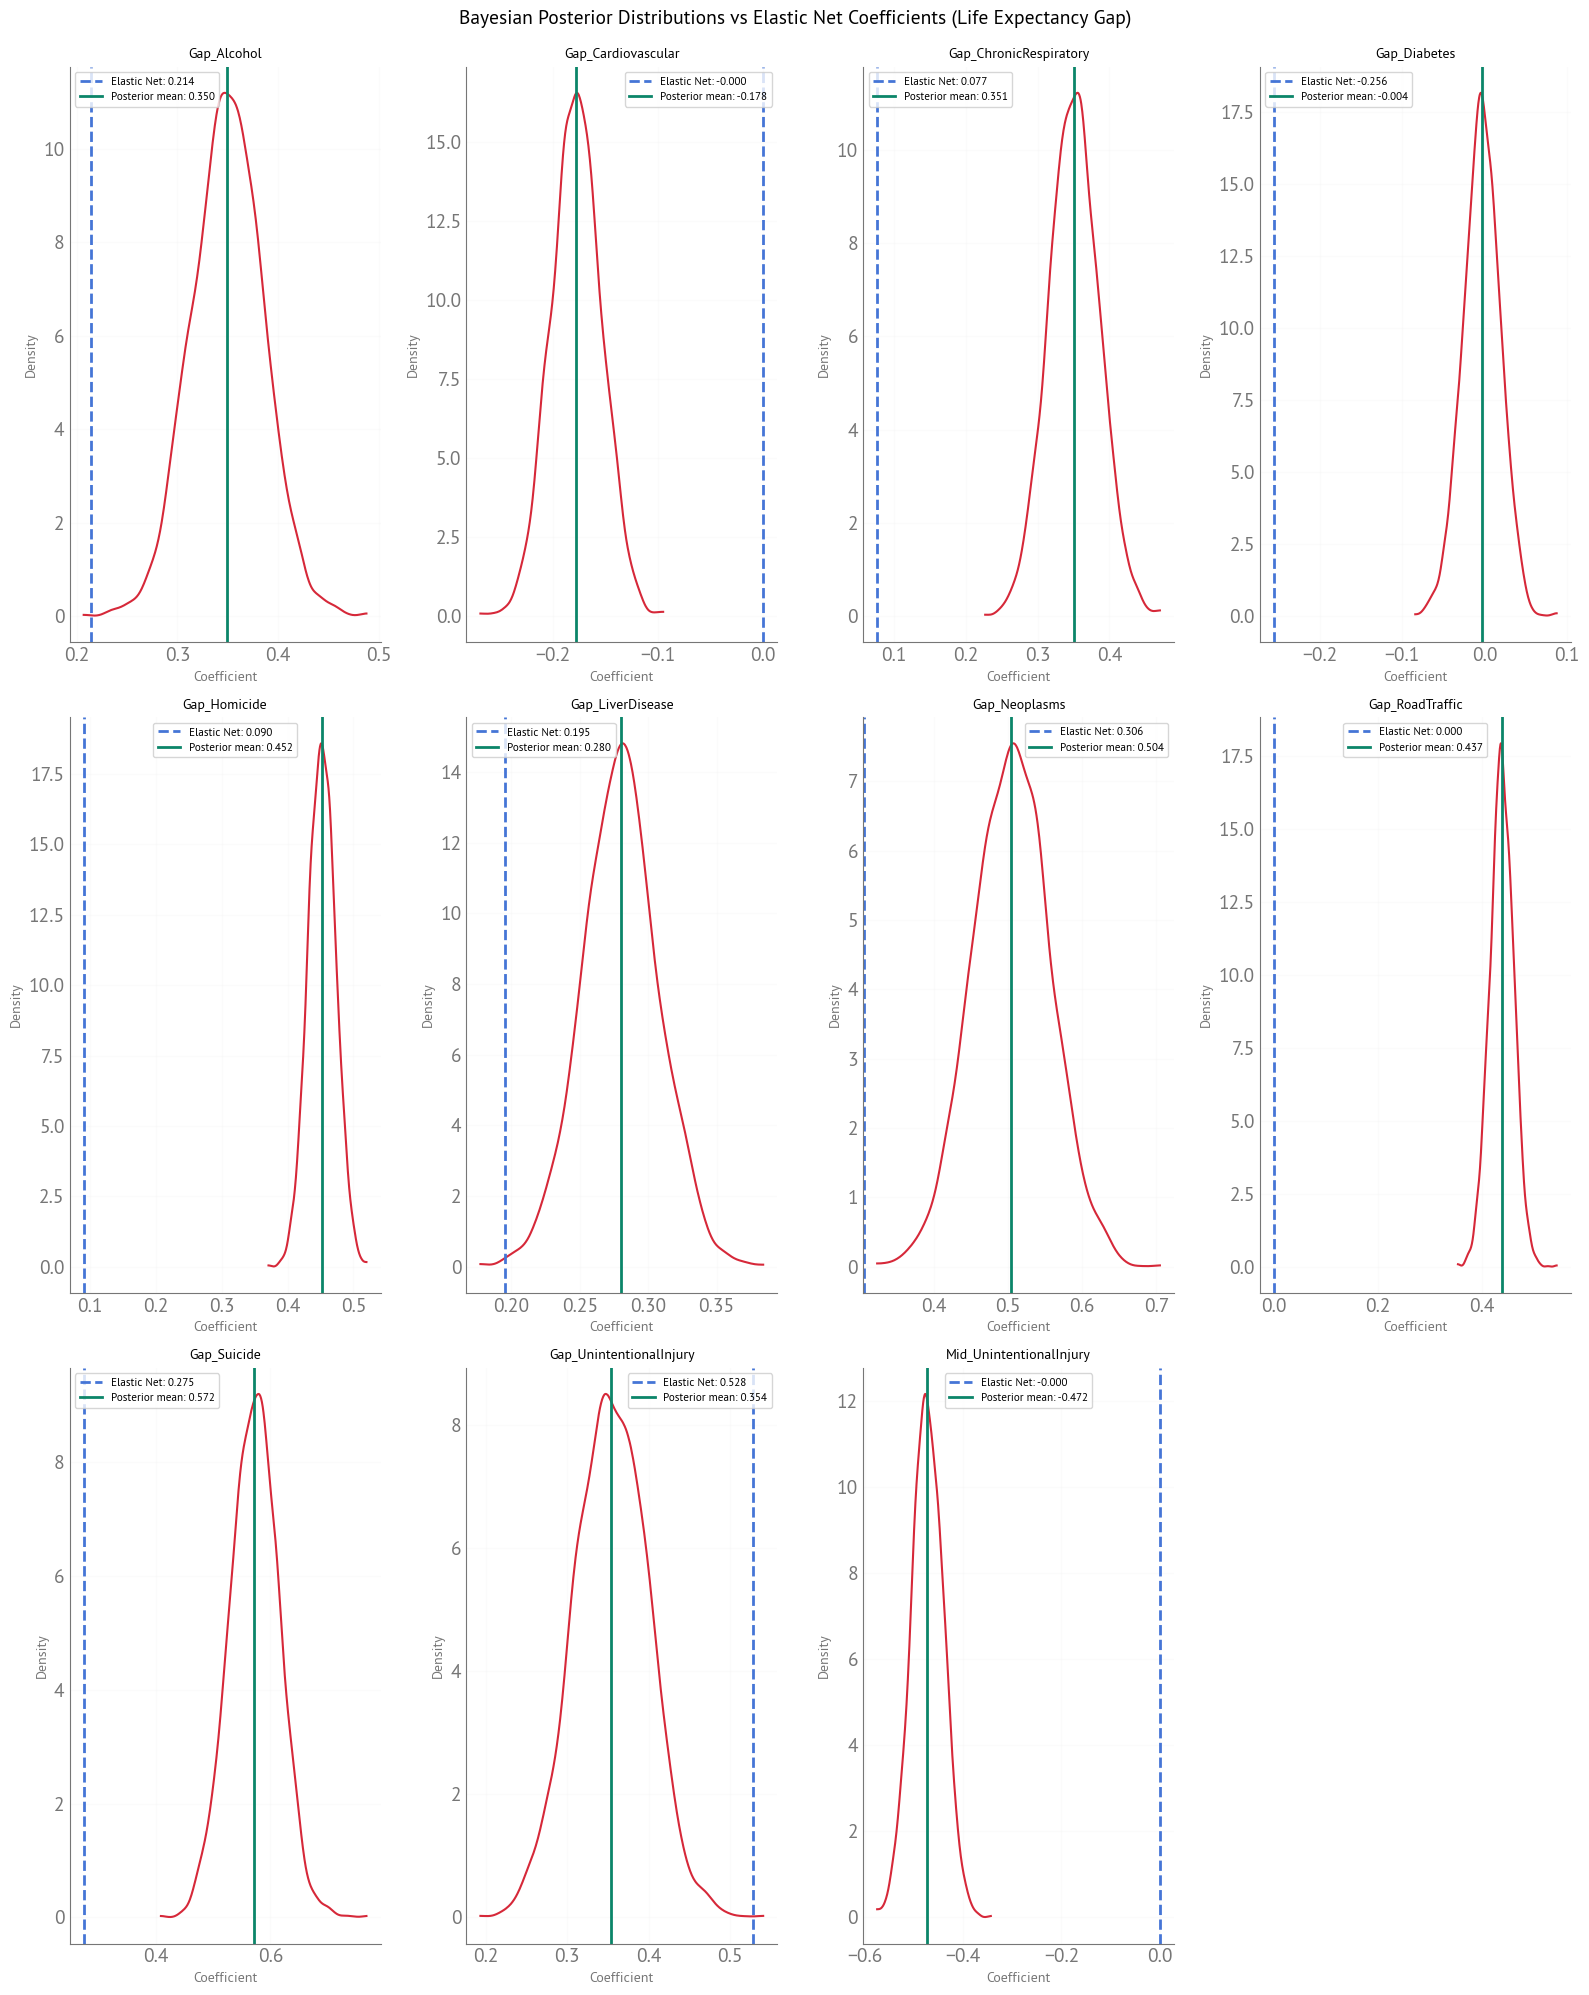

In [72]:
# Create comparison visualization using the function
plot_bayesian_elasticnet_comparison(
    beta_samples_df_le,
    elastic_net_coefs_le,
    common_predictors_le,
    title='Bayesian Posterior Distributions vs Elastic Net Coefficients (Life Expectancy Gap)',
    output_filename='jb/figs/bayesian_elasticnet_comparison_le.png'
)

In [73]:
# Create summary comparison table
comparison_table_le = pd.DataFrame({
    'Predictor': common_predictors_le,
    'ElasticNet_Coefficient': [elastic_net_coefs_le.loc[p, 'ElasticNet_Coefficient'] for p in common_predictors_le],
    'Bayesian_Mean': [beta_samples_df_le[p].mean() for p in common_predictors_le],
    'Bayesian_Std': [beta_samples_df_le[p].std() for p in common_predictors_le],
    'Bayesian_CI_Lower': [np.percentile(beta_samples_df_le[p].values, 2.5) for p in common_predictors_le],
    'Bayesian_CI_Upper': [np.percentile(beta_samples_df_le[p].values, 97.5) for p in common_predictors_le],
    'Difference': [beta_samples_df_le[p].mean() - elastic_net_coefs_le.loc[p, 'ElasticNet_Coefficient'] 
                   for p in common_predictors_le]
})

comparison_table_le = comparison_table_le.sort_values('ElasticNet_Coefficient', key=abs, ascending=False)
comparison_table_le.head(20)

,Predictor,ElasticNet_Coefficient,Bayesian_Mean,Bayesian_Std,Bayesian_CI_Lower,Bayesian_CI_Upper,Difference
9,Gap_UnintentionalInjury,0.528076,0.354002,0.045071,0.265162,0.440756,-0.174074
6,Gap_Neoplasms,0.306021,0.504316,0.051874,0.402584,0.606410,0.198295
8,Gap_Suicide,0.274845,0.571844,0.042770,0.486631,0.653260,0.296999
3,Gap_Diabetes,-0.256190,-0.003601,0.022560,-0.048703,0.039746,0.252589
0,Gap_Alcohol,0.213706,0.349559,0.035569,0.280378,0.419799,0.135853
5,Gap_LiverDisease,0.195095,0.279811,0.028066,0.223895,0.335001,0.084716
4,Gap_Homicide,0.090231,0.452139,0.020716,0.411884,0.492728,0.361908
2,Gap_ChronicRespiratory,0.076567,0.350576,0.035088,0.282578,0.420745,0.274008
1,Gap_Cardiovascular,-0.000000,-0.177994,0.023930,-0.224531,-0.131041,-0.177994
7,Gap_RoadTraffic,0.000000,0.437481,0.022921,0.391425,0.481927,0.437481


## Model Evaluation: Posterior Predictive Checks, WAIC, and LOO-CV

### Helper Functions for Model Evaluation

In [74]:
def generate_posterior_predictive_samples(model, trace):
    """
    Generate posterior predictive samples from a PyMC model.
    
    Parameters
    ----------
    model : pymc.Model
        PyMC model object
    trace : arviz.InferenceData
        Posterior trace from MCMC sampling
        
    Returns
    -------
    ppc : arviz.InferenceData
        InferenceData object with posterior predictive samples
    """
    with model:
        ppc = pm.sample_posterior_predictive(trace, extend_inferencedata=True)
    return ppc


def extract_ppc_data(ppc, y_obs):
    """
    Extract and reshape posterior predictive data.
    
    Parameters
    ----------
    ppc : arviz.InferenceData
        InferenceData object with posterior predictive samples
    y_obs : array-like
        Observed data
        
    Returns
    -------
    y_ppc_flat : ndarray
        Flattened posterior predictive samples (chains * draws, obs)
    """
    y_ppc = ppc.posterior_predictive["y_obs"].values
    # Reshape: (chains, draws, obs) -> (chains * draws, obs)
    y_ppc_flat = y_ppc.reshape(-1, y_ppc.shape[-1])
    return y_ppc_flat


def plot_ppc_distributions(ppc, y_obs, y_ppc_flat, title, xlabel, output_filename):
    """
    Plot posterior predictive check: distribution comparison and Q-Q plot.
    
    Parameters
    ----------
    ppc : arviz.InferenceData
        InferenceData object with posterior predictive samples
    y_obs : array-like
        Observed data
    y_ppc_flat : ndarray
        Flattened posterior predictive samples
    title : str
        Title prefix for plots
    xlabel : str
        X-axis label
    output_filename : str
        Filename to save the figure
    """
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Plot 1: Overlay of observed vs posterior predictive distributions
    ax = axes[0]
    az.plot_ppc(ppc, ax=ax, num_pp_samples=100)
    ax.set_title(f"Posterior Predictive Check: Distribution Comparison ({title})")
    ax.set_xlabel(xlabel)
    
    # Plot 2: Q-Q plot comparing observed vs posterior predictive quantiles
    ax = axes[1]
    # Compute quantiles for observed data and all posterior predictive samples (pooled)
    qs = np.linspace(0, 100, 100)
    obs_quantiles = np.percentile(y_obs, qs)
    # Pool all posterior predictive draws and compute quantiles
    ppc_quantiles = np.percentile(y_ppc_flat.ravel(), qs)
    ax.scatter(obs_quantiles, ppc_quantiles, alpha=0.6, color=AIBM_COLORS['crimson'])
    # Add diagonal line
    min_val = min(obs_quantiles.min(), ppc_quantiles.min())
    max_val = max(obs_quantiles.max(), ppc_quantiles.max())
    ax.plot([min_val, max_val], [min_val, max_val], 'k--', linewidth=2, label='Perfect fit')
    ax.set_xlabel("Observed Quantiles")
    ax.set_ylabel("Posterior Predictive Quantiles")
    ax.set_title(f"Q-Q Plot: Observed vs Posterior Predictive ({title})")
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    # Update output filename with suffix
    output_filename_suffixed = get_output_filename(output_filename, MID_PREDICTORS_TO_INCLUDE, INCLUDE_YEAR_EFFECTS)
    plt.savefig(output_filename_suffixed, dpi=300, bbox_inches='tight')
    plt.show()


def plot_ppc_test_statistics(y_obs, y_ppc_flat, output_filename):
    """
    Plot posterior predictive check: test statistics comparison.
    
    Parameters
    ----------
    y_obs : array-like
        Observed data
    y_ppc_flat : ndarray
        Flattened posterior predictive samples
    output_filename : str
        Filename to save the figure
    """
    # Compute test statistics
    obs_mean = y_obs.mean()
    ppc_mean = y_ppc_flat.mean(axis=1)
    
    obs_std = y_obs.std()
    ppc_std = y_ppc_flat.std(axis=1)
    
    obs_min = y_obs.min()
    ppc_min = y_ppc_flat.min(axis=1)
    
    obs_max = y_obs.max()
    ppc_max = y_ppc_flat.max(axis=1)
    
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    axes = axes.flatten()
    
    test_stats = [
        ("Mean", obs_mean, ppc_mean),
        ("Standard Deviation", obs_std, ppc_std),
        ("Minimum", obs_min, ppc_min),
        ("Maximum", obs_max, ppc_max),
    ]
    
    for i, (name, obs_val, ppc_vals) in enumerate(test_stats):
        ax = axes[i]
        ax.hist(ppc_vals, bins=50, alpha=0.7, color=AIBM_COLORS['blue'], label='Posterior Predictive')
        ax.axvline(obs_val, color=AIBM_COLORS['crimson'], linewidth=2, linestyle='--', 
                   label=f'Observed: {obs_val:.3f}')
        # Compute p-value (proportion of ppc values more extreme than observed)
        p_value = np.mean(np.abs(ppc_vals - ppc_vals.mean()) >= np.abs(obs_val - ppc_vals.mean()))
        ax.set_xlabel(name)
        ax.set_ylabel('Density')
        ax.set_title(f'{name} Test Statistic\n(p-value: {p_value:.3f})')
        ax.legend()
        ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    # Update output filename with suffix
    output_filename_suffixed = get_output_filename(output_filename, MID_PREDICTORS_TO_INCLUDE, INCLUDE_YEAR_EFFECTS)
    plt.savefig(output_filename_suffixed, dpi=300, bbox_inches='tight')
    plt.show()


def compute_model_metrics(model, trace, model_name):
    """
    Compute WAIC and LOO-CV metrics for a model.
    
    Parameters
    ----------
    model : pymc.Model
        PyMC model object
    trace : arviz.InferenceData
        Posterior trace from MCMC sampling
    model_name : str
        Name of the model (for printing)
        
    Returns
    -------
    waic : arviz.Waic
        WAIC object
    loo : arviz.Loo
        LOO object
    """
    with model:
        waic = az.waic(trace, pointwise=True)  # elpd_waic
        loo = az.loo(trace, pointwise=True)    # elpd_loo
    
    waic_elpd = waic.elpd_waic
    loo_elpd = loo.elpd_loo
    
    print(f"{model_name} - Model Comparison Metrics:")
    print(f"WAIC (ELPD): {waic_elpd:.2f} (SE: {waic.se:.2f})")
    print(f"LOO (ELPD):  {loo_elpd:.2f} (SE: {loo.se:.2f})")
    print(f"\nEffective number of parameters:")
    print(f"  WAIC p_waic: {waic.p_waic:.2f}")
    print(f"  LOO  p_loo:  {loo.p_loo:.2f}")
    
    return waic, loo


def plot_waic_loo(waic, loo, model_name, output_filename):
    """
    Plot WAIC and LOO pointwise contributions.
    
    Parameters
    ----------
    waic : arviz.Waic
        WAIC object
    loo : arviz.Loo
        LOO object
    model_name : str
        Name of the model (for plot titles)
    output_filename : str
        Filename to save the figure
    """
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # WAIC pointwise
    ax = axes[0]
    ax.scatter(range(len(waic.waic_i)), waic.waic_i, alpha=0.6, color=AIBM_COLORS['crimson'])
    ax.axhline(0, color='k', linestyle='--', linewidth=1)
    ax.set_xlabel("Observation Index")
    ax.set_ylabel("Pointwise WAIC Contribution")
    ax.set_title(f"Pointwise WAIC Contributions ({model_name})")
    ax.grid(True, alpha=0.3)
    
    # LOO pointwise
    ax = axes[1]
    ax.scatter(range(len(loo.loo_i)), loo.loo_i, alpha=0.6, color=AIBM_COLORS['blue'])
    ax.axhline(0, color='k', linestyle='--', linewidth=1)
    ax.set_xlabel("Observation Index")
    ax.set_ylabel("Pointwise LOO Contribution")
    ax.set_title(f"Pointwise LOO Contributions ({model_name})")
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    # Update output filename with suffix
    output_filename_suffixed = get_output_filename(output_filename, MID_PREDICTORS_TO_INCLUDE, INCLUDE_YEAR_EFFECTS)
    plt.savefig(output_filename_suffixed, dpi=300, bbox_inches='tight')
    plt.show()


def check_pareto_k(loo, data, model_name, threshold=0.7):
    """
    Check Pareto k values to identify problematic observations.
    
    Pareto k > 0.7 indicates potentially problematic observations where
    LOO-CV may be unreliable.
    
    Parameters
    ----------
    loo : arviz.Loo
        LOO object
    data : dict
        Data dictionary from prepare_panel_data
    model_name : str
        Name of the model (for printing)
    threshold : float
        Threshold for problematic observations (default: 0.7)
        
    Returns
    -------
    problematic : pandas.DataFrame
        DataFrame with observations having Pareto k > threshold
    """
    pareto_k = loo.pareto_k
    
    # Find problematic observations
    problematic_mask = pareto_k > threshold
    n_problematic = problematic_mask.sum()
    
    print(f"\nPareto k diagnostics ({model_name}):")
    print(f"  Observations with k > {threshold}: {n_problematic} ({100*n_problematic/len(pareto_k):.1f}%)")
    print(f"  Maximum Pareto k: {pareto_k.max():.3f}")
    print(f"  Mean Pareto k: {pareto_k.mean():.3f}")
    print(f"  Median Pareto k: {np.median(pareto_k):.3f}")
    
    if n_problematic > 0:
        problematic_df = pd.DataFrame({
            'Observation': np.where(problematic_mask)[0],
            'Pareto_k': pareto_k[problematic_mask],
            'Country': [data["meta"]["countries"][data["country_idx"][i]] 
                       for i in np.where(problematic_mask)[0]],
            'Year': [data["meta"]["years"][data["year_idx"][i]] 
                    for i in np.where(problematic_mask)[0]]
        })
        problematic_df = problematic_df.sort_values('Pareto_k', ascending=False)
        print(f"\n  Top problematic observations (k > {threshold}):")
        print(problematic_df.head(10).to_string(index=False))
        return problematic_df
    else:
        print(f"  No observations exceed threshold (k > {threshold})")
        return pd.DataFrame()


def identify_influential_observations(loo, data, model_name, output_filename, top_n=10):
    """
    Identify observations with high influence (high |LOO contribution|).
    
    Parameters
    ----------
    loo : arviz.Loo
        LOO object
    data : dict
        Data dictionary from prepare_panel_data
    model_name : str
        Name of the model (for printing)
    output_filename : str
        Filename to save HTML table
    top_n : int
        Number of top influential observations to return (default: 10)
        
    Returns
    -------
    top_influential : pandas.DataFrame
        DataFrame with top influential observations
    """
    loo_i_df = pd.DataFrame({
        'Observation': range(len(loo.loo_i)),
        'LOO_i': loo.loo_i,
        'Abs_LOO_i': np.abs(loo.loo_i),
        'Pareto_k': loo.pareto_k
    })
    
    # Get top N most influential observations
    top_influential = loo_i_df.nlargest(top_n, 'Abs_LOO_i')
    print(f"Top {top_n} most influential observations ({model_name}):")
    print(top_influential)
    
    # Add country and year information
    top_influential['Country'] = [data["meta"]["countries"][data["country_idx"][i]] 
                                  for i in top_influential['Observation']]
    top_influential['Year'] = [data["meta"]["years"][data["year_idx"][i]] 
                              for i in top_influential['Observation']]
    
    # Write to HTML table (update filename with suffix)
    output_filename_suffixed = get_output_filename(output_filename, MID_PREDICTORS_TO_INCLUDE, INCLUDE_YEAR_EFFECTS)
    write_html_table(
        top_influential[['Country', 'Year', 'LOO_i', 'Pareto_k']].rename(
            columns={'LOO_i': 'LOO Contribution', 'Pareto_k': 'Pareto k'}
        ),
        output_filename_suffixed
    )
    
    return top_influential[['Observation', 'Country', 'Year', 'LOO_i', 'Abs_LOO_i', 'Pareto_k']]

### HALE Gap Model Evaluation

#### Posterior Predictive Checks

Posterior predictive checks compare observed data to data simulated from the posterior distribution to assess model fit.

In [75]:
# Generate posterior predictive samples for HALE model
ppc_hale = generate_posterior_predictive_samples(model_hale, trace_hale)

Sampling: [y_obs]


Output()

In [76]:
# Extract observed and posterior predictive data
y_obs_hale = data_hale["y_centered"]
y_ppc_hale_flat = extract_ppc_data(ppc_hale, y_obs_hale)

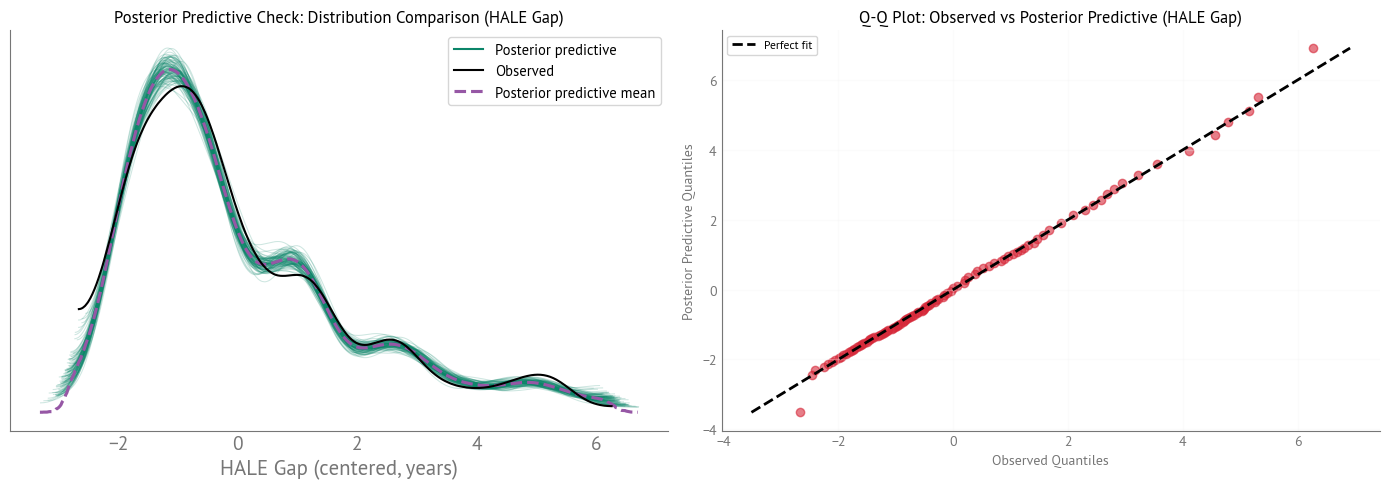

In [77]:
# Plot posterior predictive check: distribution comparison and Q-Q plot
plot_ppc_distributions(
    ppc_hale, y_obs_hale, y_ppc_hale_flat,
    title="HALE Gap",
    xlabel="HALE Gap (centered, years)",
    output_filename='jb/figs/ppc_hale.png'
)

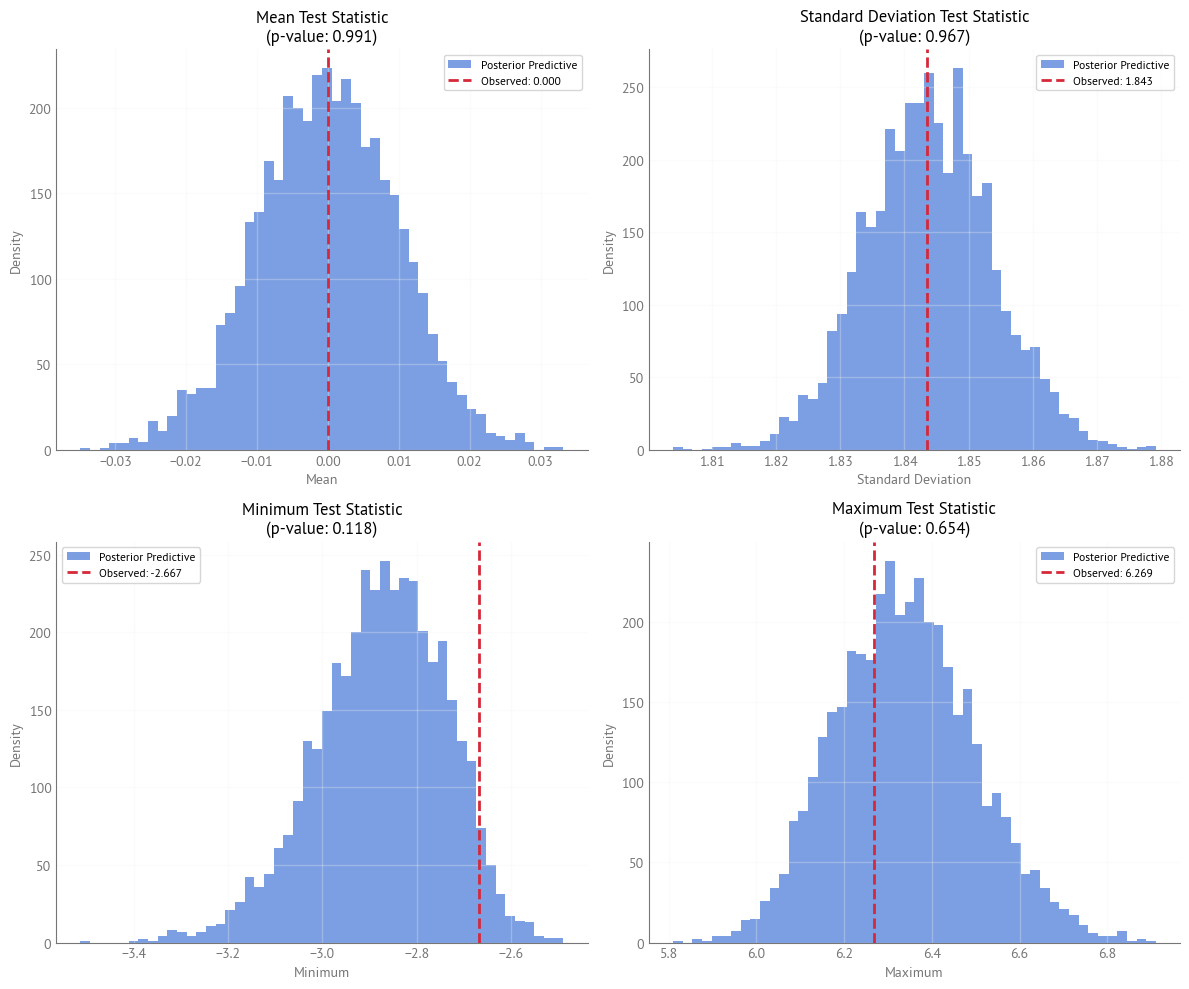

In [78]:
# Posterior predictive check: test statistics
plot_ppc_test_statistics(
    y_obs_hale, y_ppc_hale_flat,
    output_filename='jb/figs/ppc_test_stats_hale.png'
)

#### WAIC and LOO-CV

Compute Widely Applicable Information Criterion (WAIC) and Leave-One-Out Cross-Validation (LOO-CV) to assess model fit and compare models.

In [79]:
# Compute WAIC and LOO-CV for HALE model
waic_hale, loo_hale = compute_model_metrics(model_hale, trace_hale, "HALE Gap Model")

/home/downey/miniconda3/envs/EqualityWEF/lib/python3.13/site-packages/arviz/stats/stats.py:1667: UserWarning: For one or more samples the posterior variance of the log predictive densities exceeds 0.4. This could be indication of WAIC starting to fail. 
See http://arxiv.org/abs/1507.04544 for details
  warnings.warn(


HALE Gap Model - Model Comparison Metrics:
WAIC (ELPD): 154.66 (SE: 23.30)
LOO (ELPD):  154.24 (SE: 23.33)

Effective number of parameters:
  WAIC p_waic: 52.65
  LOO  p_loo:  53.06


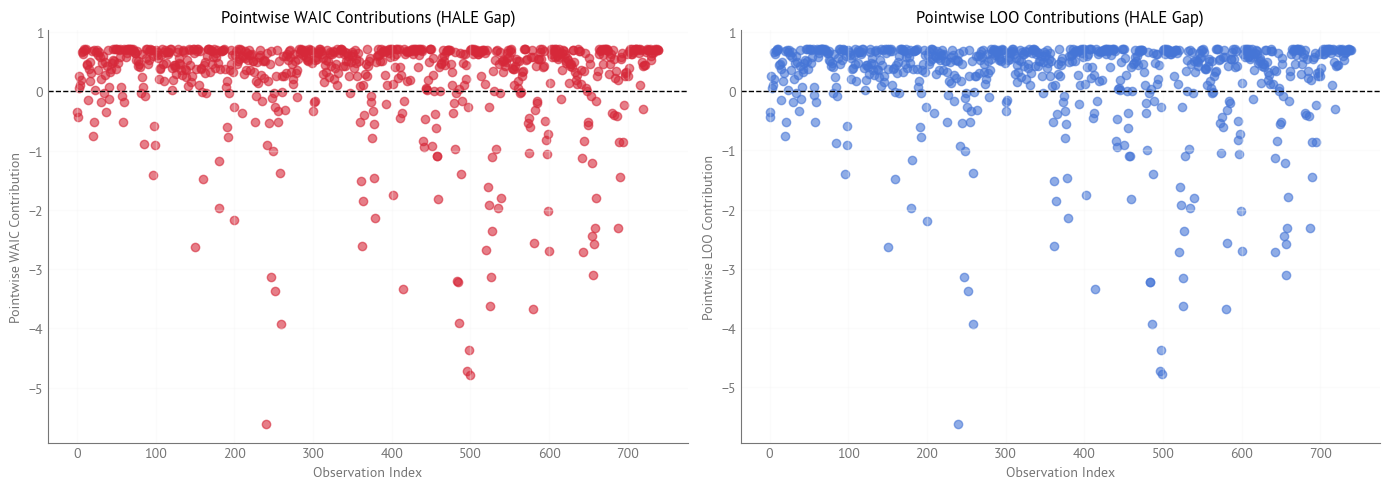

In [80]:
# Plot WAIC and LOO pointwise contributions
plot_waic_loo(
    waic_hale, loo_hale,
    model_name="HALE Gap",
    output_filename='jb/figs/waic_loo_hale.png'
)

In [81]:
# Check Pareto k values for problematic observations
problematic_hale = check_pareto_k(loo_hale, data_hale, model_name="HALE Gap")


Pareto k diagnostics (HALE Gap):
  Observations with k > 0.7: <xarray.DataArray 'pareto_shape' ()> Size: 8B
array(0) (0.0%)
  Maximum Pareto k: 0.490
  Mean Pareto k: 0.117
  Median Pareto k: 0.111
  No observations exceed threshold (k > 0.7)


In [82]:
# Identify observations with high influence (high |LOO contribution|)
top_influential_hale = identify_influential_observations(
    loo_hale, data_hale,
    model_name="HALE Gap",
    output_filename='jb/tables/influential_observations_hale.html'
)
top_influential_hale

Top 10 most influential observations (HALE Gap):
     Observation     LOO_i  Abs_LOO_i  Pareto_k
240          240 -5.618911   5.618911  0.373658
499          499 -4.775942   4.775942  0.308985
496          496 -4.719278   4.719278  0.406190
498          498 -4.370171   4.370171  0.285571
259          259 -3.927115   3.927115  0.410153
486          486 -3.926355   3.926355  0.399075
580          580 -3.671701   3.671701  0.220170
525          525 -3.622863   3.622863  0.345947
252          252 -3.371083   3.371083  0.240686
414          414 -3.334804   3.334804  0.281269


,Observation,Country,Year,LOO_i,Abs_LOO_i,Pareto_k
240,240,EST,2000,-5.618911,5.618911,0.373658
499,499,LTU,2019,-4.775942,4.775942,0.308985
496,496,LTU,2016,-4.719278,4.719278,0.406190
498,498,LTU,2018,-4.370171,4.370171,0.285571
259,259,EST,2019,-3.927115,3.927115,0.410153
486,486,LTU,2006,-3.926355,3.926355,0.399075
580,580,NOR,2000,-3.671701,3.671701,0.220170
525,525,LVA,2005,-3.622863,3.622863,0.345947
252,252,EST,2012,-3.371083,3.371083,0.240686
414,414,ISR,2014,-3.334804,3.334804,0.281269


### Life Expectancy Gap Model Evaluation

#### Posterior Predictive Checks

In [83]:
# Generate posterior predictive samples for Life Expectancy model
ppc_le = generate_posterior_predictive_samples(model_le, trace_le)

Sampling: [y_obs]


Output()

In [84]:
# Extract observed and posterior predictive data
y_obs_le = data_le["y_centered"]
y_ppc_le_flat = extract_ppc_data(ppc_le, y_obs_le)

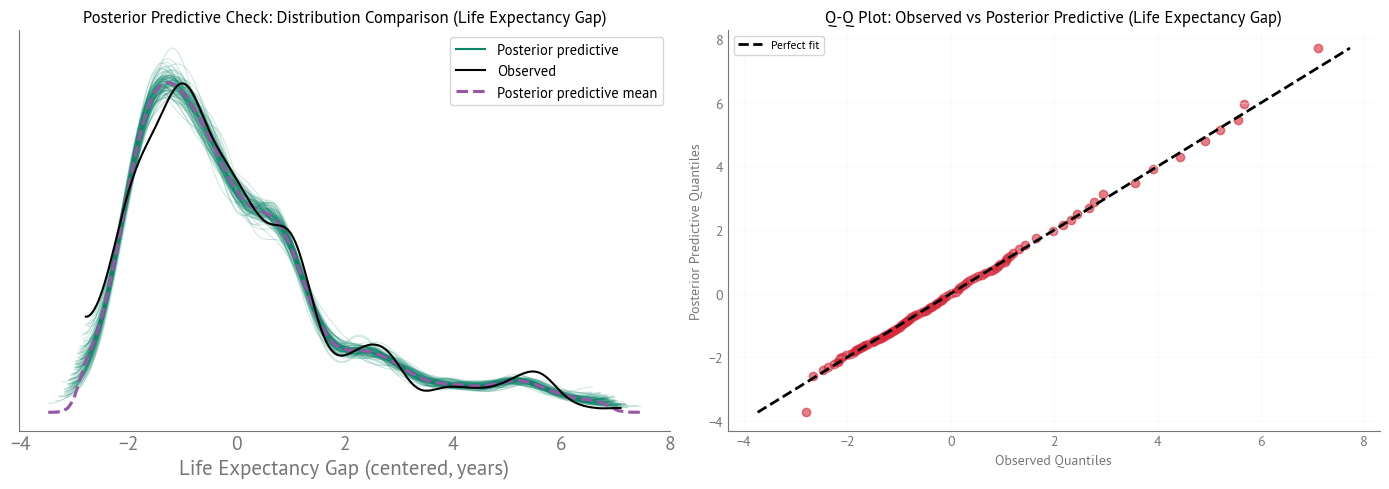

In [85]:
# Plot posterior predictive check: distribution comparison and Q-Q plot
plot_ppc_distributions(
    ppc_le, y_obs_le, y_ppc_le_flat,
    title="Life Expectancy Gap",
    xlabel="Life Expectancy Gap (centered, years)",
    output_filename='jb/figs/ppc_le.png'
)

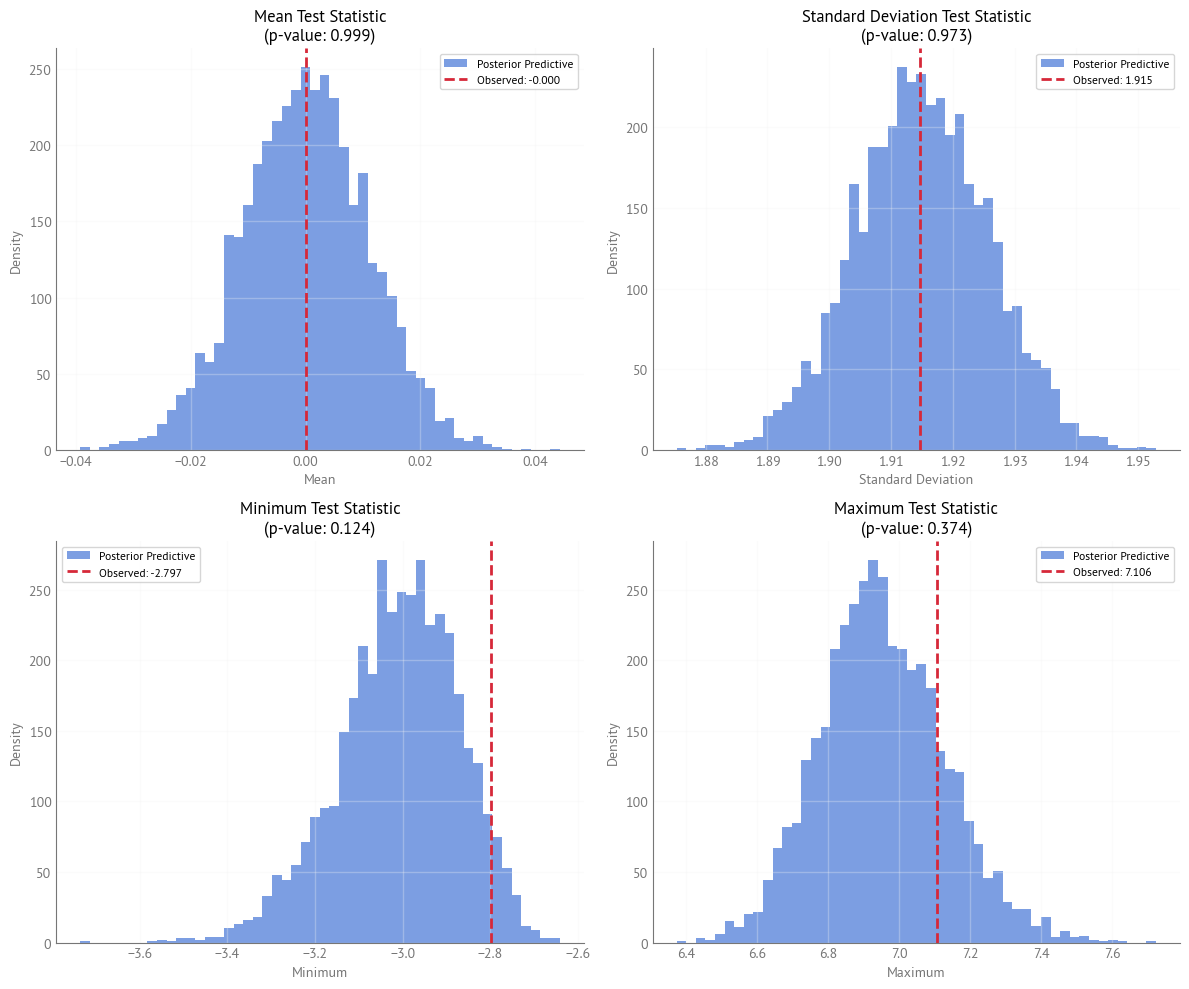

In [86]:
# Posterior predictive check: test statistics
plot_ppc_test_statistics(
    y_obs_le, y_ppc_le_flat,
    output_filename='jb/figs/ppc_test_stats_le.png'
)

#### WAIC and LOO-CV

In [87]:
# Compute WAIC and LOO-CV for Life Expectancy model
waic_le, loo_le = compute_model_metrics(model_le, trace_le, "Life Expectancy Gap Model")

/home/downey/miniconda3/envs/EqualityWEF/lib/python3.13/site-packages/arviz/stats/stats.py:1667: UserWarning: For one or more samples the posterior variance of the log predictive densities exceeds 0.4. This could be indication of WAIC starting to fail. 
See http://arxiv.org/abs/1507.04544 for details
  warnings.warn(


Life Expectancy Gap Model - Model Comparison Metrics:
WAIC (ELPD): 83.66 (SE: 24.45)
LOO (ELPD):  83.16 (SE: 24.49)

Effective number of parameters:
  WAIC p_waic: 53.47
  LOO  p_loo:  53.97


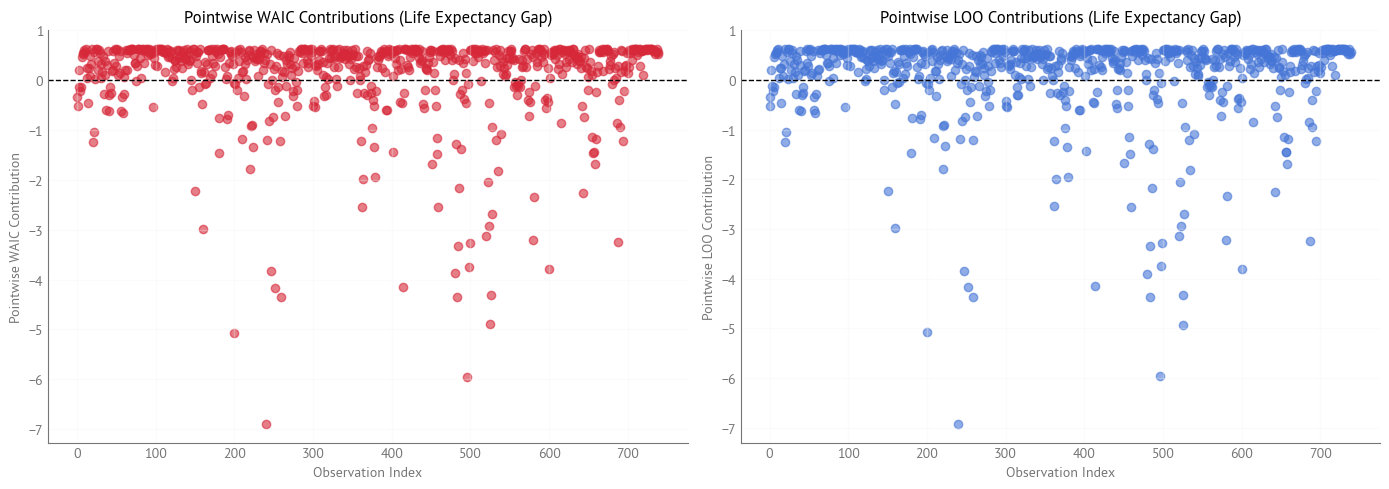

In [88]:
# Plot WAIC and LOO pointwise contributions
plot_waic_loo(
    waic_le, loo_le,
    model_name="Life Expectancy Gap",
    output_filename='jb/figs/waic_loo_le.png'
)

In [89]:
# Check Pareto k values for problematic observations
problematic_le = check_pareto_k(loo_le, data_le, model_name="Life Expectancy Gap")


Pareto k diagnostics (Life Expectancy Gap):
  Observations with k > 0.7: <xarray.DataArray 'pareto_shape' ()> Size: 8B
array(0) (0.0%)
  Maximum Pareto k: 0.606
  Mean Pareto k: 0.109
  Median Pareto k: 0.098
  No observations exceed threshold (k > 0.7)


In [90]:
# Identify observations with high influence (high |LOO contribution|)
top_influential_le = identify_influential_observations(
    loo_le, data_le,
    model_name="Life Expectancy Gap",
    output_filename='jb/tables/influential_observations_le.html'
)
top_influential_le

Top 10 most influential observations (Life Expectancy Gap):
     Observation     LOO_i  Abs_LOO_i  Pareto_k
240          240 -6.916922   6.916922  0.473168
496          496 -5.961650   5.961650  0.345511
200          200 -5.068263   5.068263  0.299548
525          525 -4.920357   4.920357  0.485606
259          259 -4.364052   4.364052  0.605875
483          483 -4.362741   4.362741  0.426771
526          526 -4.321751   4.321751  0.392562
252          252 -4.163552   4.163552  0.269653
414          414 -4.142512   4.142512  0.111188
480          480 -3.910877   3.910877  0.542811


,Observation,Country,Year,LOO_i,Abs_LOO_i,Pareto_k
240,240,EST,2000,-6.916922,6.916922,0.473168
496,496,LTU,2016,-5.961650,5.961650,0.345511
200,200,DNK,2000,-5.068263,5.068263,0.299548
525,525,LVA,2005,-4.920357,4.920357,0.485606
259,259,EST,2019,-4.364052,4.364052,0.605875
483,483,LTU,2003,-4.362741,4.362741,0.426771
526,526,LVA,2006,-4.321751,4.321751,0.392562
252,252,EST,2012,-4.163552,4.163552,0.269653
414,414,ISR,2014,-4.142512,4.142512,0.111188
480,480,LTU,2000,-3.910877,3.910877,0.542811


### Model Comparison Summary

In [91]:
# Create summary table comparing HALE and Life Expectancy models
# Both WAIC and LOO are on ELPD scale
model_comparison = pd.DataFrame({
    'Model': ['HALE Gap', 'Life Expectancy Gap'],
    'WAIC (ELPD)': [waic_hale.elpd_waic, waic_le.elpd_waic],
    'WAIC_SE': [waic_hale.se, waic_le.se],
    'LOO (ELPD)': [loo_hale.elpd_loo, loo_le.elpd_loo],
    'LOO_SE': [loo_hale.se, loo_le.se],
    'p_waic': [waic_hale.p_waic, waic_le.p_waic],
    'p_loo': [loo_hale.p_loo, loo_le.p_loo],
})

print("Model Comparison Summary:")
print(model_comparison.to_string(index=False))

Model Comparison Summary:
              Model  WAIC (ELPD)   WAIC_SE  LOO (ELPD)    LOO_SE    p_waic     p_loo
           HALE Gap    154.65545 23.295530  154.242138 23.327445 52.645384 53.058696
Life Expectancy Gap     83.66209 24.445864   83.164178 24.492377 53.469956 53.967868


In [92]:
# Write model comparison table to HTML
write_html_table(model_comparison, get_output_filename('jb/tables/model_comparison_metrics.html', MID_PREDICTORS_TO_INCLUDE, INCLUDE_YEAR_EFFECTS))

## Next Steps

- ✅ Posterior predictive checks
- ✅ WAIC and LOO-CV
- Counterfactual analysis with uncertainty quantification
- Model extensions (year fixed effects, AR(1) structure)



In [93]:
from utils import beep

beep()